<style>
.rtl-fa {
    direction: rtl;
    text-align: right;
}
.rtl-fa ul, .rtl-fa ol {
    padding-right: 2em;
    padding-left: 0;
}
.rtl-fa blockquote {
    border-left: none !important;
    border-right: 4px solid #dfe2e5;
    padding-left: 0 !important;
    padding-right: 1em;
    margin-left: 0;
    margin-right: 0;
}
.rtl-fa table {
    direction: rtl;
    margin-left: auto;
    margin-right: 0;
}
.rtl-fa th, .rtl-fa td {
    text-align: right !important;
}
.rtl-fa code, .rtl-fa pre, .rtl-fa kbd, .rtl-fa samp,
.rtl-fa .MathJax, .rtl-fa mjx-container {
    direction: ltr !important;
    unicode-bidi: isolate;
}
.rtl-fa pre {
    text-align: left !important;
}
</style>

<div class="rtl-fa" dir="rtl" style="text-align: right;">

# هفته ۱۱ — تکلیف: فراتر از تمرین کلاسی

> **سؤال اصلی:** در تمرین کلاسی دیدیم که روی یک دیتاست کوچک و ساده، استفاده از ویژگی‌های ازپیش‌آموزش‌دیده و فریزکردن backbone بهتر از آموزش مدل از صفر جواب می‌دهد. آیا وقتی دیتاست واقعاً سخت‌تر شود، این روش هنوز هم خوب کار می‌کند؟ و اگر «فقط backbone را فریز کن» کافی نبود، قدم بعدی چیست؟

## مرور کلی تکلیف

- **زمان پیشنهادی:** حدود ۶ تا ۸ ساعت؛ می‌توانید در طول هفته هرطور که برایتان مناسب است تقسیمش کنید.
- — دیتاست جدید، مقاله‌های جدید و چند قابلیت جدید در PyTorch دارید که قبلاً استفاده نکرده‌اید (مثل parameter groups، hookها و ترکیب دستی batchها). هیچ بخشی از این تکلیف صرفاً با کپی‌کردن بدون تغییرِ کدهای تمرین کلاسی حل نمی‌شود.
- **دیتاست جدید:** **Oxford-IIIT Pet Dataset** — شامل ۳۷ نژاد حیوان خانگی با عکس‌های واقعی و در دسترس از طریق `torchvision.datasets.OxfordIIITPet`. این مسئله واقعاً از زیرمجموعه‌ی ۴کلاسه‌ی CIFAR-10 در تمرین کلاسی سخت‌تر است: دسته‌بندی ریزدانه است (مثلاً Bombay cat و Russian Blue خیلی شبیه هم‌اند) و دیگر با یک مسئله‌ی اسباب‌بازی طرف نیستیم.
- **مقاله‌های جدید:** سه مطالعه‌ی کوتاه و هدفمند؛ برای هرکدام فقط باید به **بخش‌ها یا معادله‌های مشخص‌شده** مراجعه کنید، نه کل مقاله:
  1. Yosinski, Clune, Bengio, Lipson — *"How transferable are features in deep neural networks?"* (NeurIPS 2014).
     [arXiv:1411.1792](https://arxiv.org/abs/1411.1792)
  2. Selvaraju et al. — *"Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"* (ICCV 2017).
     [arXiv:1610.02391](https://arxiv.org/abs/1610.02391)
  3. Zhang, Cissé, Dauphin, Lopez-Paz — *"mixup: Beyond Empirical Risk Minimization"* (ICLR 2018).
     [arXiv:1710.09412](https://arxiv.org/abs/1710.09412)

## چه چیزهایی در این تکلیف واقعاً جدید است؟

| مهارت | تمرین کلاسی | این تکلیف |
|---|---|---|
| روش Transfer Learning | فقط backbone فریز بود | **Fine-tuning** — بازکردن انتخابی بعضی لایه‌ها برای آموزش |
| تنظیم Optimizer | یک learning rate برای همه‌چیز | **Parameter groups** — learning rateهای متفاوت برای بخش‌های مختلف مدل |
| درک رفتار مدل | بررسی shapeها و شمارش پارامترها | **Grad-CAM** — دیدن اینکه مدل برای تصمیم‌گیری به *کجای تصویر* نگاه می‌کند |
| Augmentation | فقط تبدیل‌های هندسی/رنگی | **mixup** — ترکیب دو تصویر و برچسب‌هایشان |
| دیتاست | زیرمجموعه‌ی ۴کلاسه‌ی CIFAR-10 (دسته‌های کلی) | عکس‌های واقعی با ۳۷ کلاس (دسته‌بندی ریزدانه) |

## مواردی که باید تحویل دهید

- [ ] یک نوت‌بوک کامل که تمام سلول‌های `# TODO` در آن تکمیل شده و قابل اجرا باشد
- [ ] پاسخ همه‌ی سؤال‌های نوشتاری با بیان خودتان
- [ ] **گزارش تأمل/جمع‌بندی نهایی** در بخش ۶ — یک جمع‌بندی کوتاه نوشتاری، نه فقط خروجی کد

شروع کنیم.

</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۰ — : PetScan (حدود ۲۰ دقیقه)

PixelWorks AI (بله، همان تیم تمرین کلاسی) یک مشتری جدید گرفته است: **PetScan**؛ استارتاپی که می‌خواهد اپی بسازد تا از روی عکس موبایل، نژاد حیوان خانگی را تشخیص دهد. برخلاف SnapSort که فقط چهار دسته‌ی کلی داشت (گربه، سگ، ماشین، کشتی)، PetScan باید **۳۷ نژاد مشخص** را تشخیص دهد؛ بعضی از این نژادها از نظر ظاهری تقریباً شبیه هم‌اند. حرف مدیرتان دقیقاً این است:
*«دفعه‌ی قبل ویژگی‌های فریز‌شده‌ی ResNet18 خیلی خوب جواب داد؛ اول همان را امتحان کن، ولی تعجب نکن اگر این بار کافی نباشد.»*

</div>


In [4]:
#================================
#          imports
#================================
from copy import deepcopy
from pathlib import Path
import random
import time
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
#✔️

#================================
#         Dataset Path
#================================
DATA_ROOT = Path("data")
#✔️

#================================
#       Set random seed
#================================
SEED = 42

def set_seed(seed=SEED):
    #python randomness
    random.seed(seed)
    #numpy randomness
    np.random.seed(seed)
    #torch randomness
    torch.manual_seed(seed)
    # GPU randomness(if available)

    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
#✔️
#================================
#         Set Device
#================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
#================================
#        ImageNet Stats
#================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

Using device: cpu


<div class="rtl-fa" dir="rtl" style="text-align: right;">

## این بار pipeline را خودتان بسازید

در تمرین کلاسی، `TransformSubset`، `make_balanced_indices` و `make_val_test_split` به‌صورت کامل در اختیار شما بود. این بار باید خودتان آن‌ها را با دیتاست جدید سازگار کنید. رابط `OxfordIIITPet` کمی با `CIFAR10` فرق دارد: فقط splitهای `"trainval"` و `"test"` را دارد و برچسب‌ها را به‌جای `.targets` در `._labels` نگه می‌دارد.

**TODO:** هر دو split دیتاست را بارگذاری کنید، اما فعلاً هیچ transformای اعمال نکنید؛ درست مثل الگوی تمرین کلاسی، transformها را بعد از ساخت subset اضافه می‌کنیم. سپس تعداد کل تصاویر و تعداد کلاس‌ها را چاپ کنید.

</div>


In [5]:
raw_trainval = OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True, transform=None)
raw_test_full = OxfordIIITPet(root=DATA_ROOT, split="test", download=True, transform=None)
#✔️

print(f"Ten example : {raw_trainval.classes}")
print( len(raw_trainval), len(raw_test_full))


Ten example : ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']
3680 3669


<div class="rtl-fa" dir="rtl" style="text-align: right;">

**TODO:** برای اینکه زمان آموزش روی لپ‌تاپ معقول بماند، با یک subset کار کنید:
برای آموزش **۲۰ تصویر از هر نژاد** و برای validation **۸ تصویر از هر نژاد** انتخاب کنید. یعنی ۳۷ × ۲۰ = ۷۴۰ تصویر آموزشی. این تمرین هم تعداد کلاس بیشتری دارد و هم تعداد کل تصاویرش از تنظیم ۴کلاسه و ۲۴۰تصویری تمرین کلاسی بیشتر است، پس انتظار نداشته باشید سرعت اجرا مثل قبل باشد.

تابع `make_balanced_indices` را برای نحوه‌ی ذخیره‌ی برچسب‌ها در این دیتاست سازگار کنید. `raw_trainval._labels` یک لیست معمولی Python از اعداد صحیح است که از قبل از ۰ شروع شده‌اند؛ بنابراین برخلاف زیرمجموعه‌ی CIFAR-10 در تمرین کلاسی، اینجا به `label_map` نیاز ندارید.

</div>


In [6]:
def make_balanced_indices(labels, n_per_class, seed=SEED):
    """This function Return idx for each class given n_per_class"""
    set_seed(seed)
    #✔️
    rng = random.Random(seed)
    chosen =[]
    # keys => class ids, values => indices
    class_indices = defaultdict(list)
    for idx,label in enumerate(labels):
        class_indices[label].append(idx)
    #✔️
    # num_classes
    num_classes = max(labels)+1
    #✔️
    for c  in range(num_classes):
        indices = class_indices[c]
        rng.shuffle(indices)
        chosen.extend(indices[:n_per_class])
    #✔️
    rng.shuffle(chosen)
    return chosen
    #✔️

train_indices = make_balanced_indices(raw_trainval._labels, n_per_class=20, seed=SEED)
val_indices = make_balanced_indices(raw_test_full._labels, n_per_class=8, seed=SEED)
#✔️

class_names = raw_trainval.classes
NUM_CLASSES = len(class_names)
print("Classes:", NUM_CLASSES)
print("Train images:", len(train_indices), "| Val images:", len(val_indices))

Classes: 37
Train images: 740 | Val images: 296


<div class="rtl-fa" dir="rtl" style="text-align: right;">

**TODO:** یک کلاس `TransformSubset` بسازید؛ همان ایده‌ی تمرین کلاسی: یک `Dataset` که دیتاست پایه، فهرست indexها و یک transform را نگه می‌دارد. اینجا به `label_map` نیازی نیست، چون برچسب‌های `OxfordIIITPet` از قبل اعداد پیوسته‌ی ۰ تا ۳۶ هستند.

</div>


In [7]:
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.indices = indices
        self.base_dataset = base_dataset
        self.transform = transform
        #✔️
    def __len__(self):
        return len(self.indices)
        #✔️
    def __getitem__(self, idx):
        image,label = self.base_dataset[self.indices[idx]]
        return self.transform(image), label
        #✔️
deterministic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
#✔️
train_dataset = TransformSubset(raw_trainval, train_indices, deterministic_transform)
val_dataset = TransformSubset(raw_test_full, val_indices, deterministic_transform)
#✔️

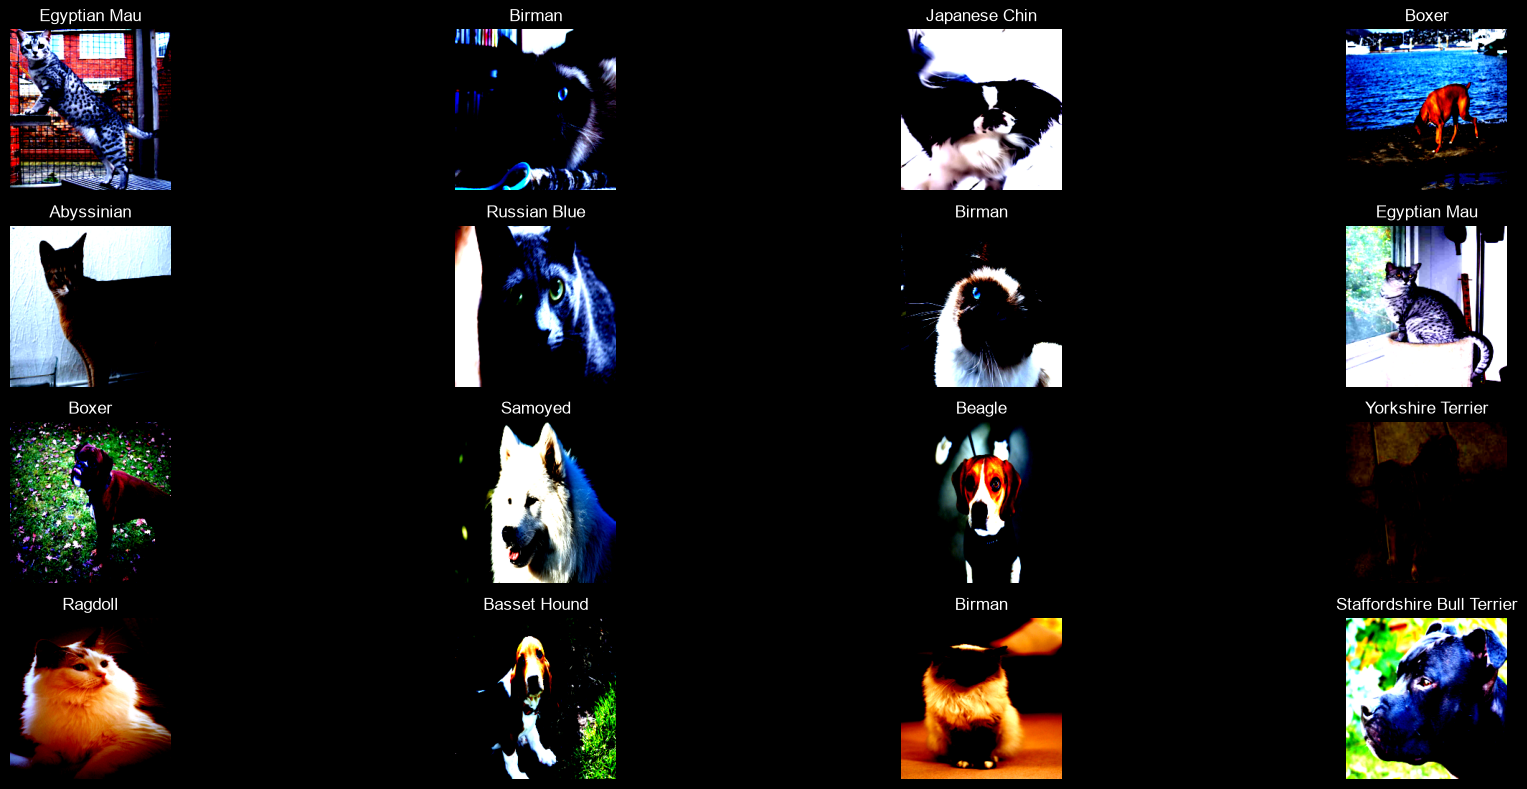

In [8]:

# Visualize 16 samples

generator = torch.Generator().manual_seed(SEED)
#✔️
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0,generator=generator)
images, labels = next(iter(train_loader))
#✔️
fig, axes = plt.subplots(4, 4, figsize=(20, 8))
#✔️
for image, label, axis in zip(images, labels, axes.flat):
    image =image.permute(1, 2, 0).clamp(0, 1)
    axis.axis("off")
    axis.imshow(image)
    axis.set_title(raw_trainval.classes[label.item()])
    axis.axis('off')
plt.tight_layout()
plt.show()
#✔️

<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q0.1 (قبل از آموزش خوب نگاه کنید):** یک شبکه‌ی `4×4` از تصاویر خام و بدون transformِ داده‌های آموزشی نمایش دهید و نام نژاد هر تصویر را به‌عنوان عنوان بنویسید. واقعاً چند جفت را با دقت نگاه کنید: آیا *خودتان* فقط از روی عکس می‌توانید دو نژاد ظاهراً شبیه را از هم تشخیص دهید؟ مثلاً دو گربه با الگوی راه‌راه مشابه یا دو نژاد تریر که شبیه هم‌اند. یک جفت نژاد از نمونه‌ی خودتان نام ببرید که تشخیصشان برایتان واقعاً سخت بود؛ یا اگر در این ۱۶ تصویر چنین جفتی پیدا نکردید، توضیح دهید چرا.

> **پاسخ شما:**
تفکیک حیوانات دراین دیتاست بسیار سخت است ( حتی برای انسان ) مثلا تفکیک دو نژاد سگ

Basset Hound & Beagle
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۱ — روشی که دفعه‌ی قبل جواب داد (حدود ۲۰ دقیقه؛ عمداً کوتاه)

قبل از اینکه سراغ روش جدیدی بروید، روش تمرین کلاسی را به‌عنوان baseline تأیید کنید: ResNet18 ازپیش‌آموزش‌دیده را بارگذاری کنید، backbone را فریز کنید، head را عوض کنید و فقط head را آموزش دهید. این کار را قبلاً انجام داده‌اید، پس این بخش عمداً کوتاه است؛ بخش جالب از قسمت ۲ شروع می‌شود.

</div>


In [9]:
def make_loader(dataset, shuffle, batch_size=16, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, generator=generator)
    #✔️

def run_epoch(model, loader, loss_fn, optimizer=None):
    set_seed(SEED)
    #✔️
    is_training = optimizer is not None
    model.eval()
    #✔️
    if is_training:
        # Only the parts of the model actually being trained go into train() mode.
        # Which parts that is will change across this homework -- more on that soon.
        for module in model.trainable_modules:
            module.train()
            #✔️
    total_loss, total_correct, total_examples = 0.0, 0, 0
    #✔️
    with torch.set_grad_enabled(is_training):
        #✔️
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            #✔️
            logits = model(images)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                #✔️
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size
            #✔️
    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}

<div class="rtl-fa" dir="rtl" style="text-align: right;">

به `model.trainable_modules` در بالا توجه کنید؛ این یک bookkeeping کوچک است که در کل این تکلیف به آن نیاز خواهید داشت. در تمرین کلاسی بخش قابل‌آموزش همیشه «فقط head» بود، اما اینجا چنین نیست.

**TODO:** baseline فریز‌شده را بسازید: وزن‌های pretrained را بارگذاری کنید، همه‌چیز را فریز کنید، head را جایگزین کنید و مقدار `feature_model.trainable_modules = [feature_model.fc]` را تنظیم کنید تا `run_epoch` بداند فقط head باید وارد حالت `.train()` شود.

</div>


In [10]:
set_seed(SEED)
weights = ResNet18_Weights.DEFAULT
#✔️
feature_model = resnet18(weights=weights)
#✔️
# TODO: freeze every parameter
for param in feature_model.parameters():
    param.requires_grad = False
    #✔️
# TODO: replace feature_model.fc with a fresh nn.Linear(..., NUM_CLASSES)
for param in feature_model.fc.parameters():
    param.requires_grad = True
    #✔️

feature_input = feature_model.fc.in_features
feature_model.fc = nn.Linear(feature_input,NUM_CLASSES)
#✔️
# TODO: feature_model = feature_model.to(DEVICE)
feature_model = feature_model.to(DEVICE)
#✔️
# TODO: feature_model.trainable_modules = [feature_model.fc]
feature_model.trainable_modules = [feature_model.fc]
#✔️
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

])

# TODO: train_dataset_aug = TransformSubset(raw_trainval, train_indices, train_transform)
train_dataset_aug = TransformSubset(raw_trainval, train_indices, train_transform)
#✔️
# TODO: train_loader = make_loader(train_dataset_aug, shuffle=True)
train_loader = make_loader(train_dataset_aug, shuffle=True)
#✔️
# TODO: val_loader = make_loader(val_dataset, shuffle=False)
val_loader = make_loader(val_dataset, shuffle=False)
#✔️
# TODO: optimizer = torch.optim.Adam(feature_model.fc.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(feature_model.fc.parameters(), lr=1e-3)
#✔️
# TODO: loss_fn = nn.CrossEntropyLoss()
loss_fn = nn.CrossEntropyLoss()
#✔️
frozen_history = {"train_accuracy": [], "val_accuracy": []}
EPOCHS = 8
for epoch in range(EPOCHS):
    train_metrics = run_epoch(feature_model, train_loader, loss_fn, optimizer=optimizer)
    val_metrics = run_epoch(feature_model, val_loader, loss_fn)
    frozen_history["train_accuracy"].append(train_metrics["accuracy"])
    frozen_history["val_accuracy"].append(val_metrics["accuracy"])
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train acc: {train_metrics['accuracy']:.1%} | val acc: {val_metrics['accuracy']:.1%}")

E:\Maktab-145\maktab_kernel\Lib\site-packages\torch\autograd\graph.py:1072: UserWarning: The detected GPU (Intel(R) UHD Graphics) is not officially supported by PyTorch XPU. Running workloads on this device may result in unexpected behavior.
For stable and fully supported execution, please use GPUs based on Intel Arc (Alchemist) series or newer.
Refer to the hardware prerequisites for more information: https://docs.pytorch.org/docs/main/notes/get_start_xpu.html#hardware-prerequisite (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\xpu\XPUFunctions.cpp:134.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01/8 | train acc: 26.4% | val acc: 59.1%
Epoch 02/8 | train acc: 75.1% | val acc: 75.3%
Epoch 03/8 | train acc: 87.0% | val acc: 78.7%
Epoch 04/8 | train acc: 92.0% | val acc: 80.4%
Epoch 05/8 | train acc: 92.4% | val acc: 84.1%
Epoch 06/8 | train acc: 96.5% | val acc: 83.1%
Epoch 07/8 | train acc: 97.3% | val acc: 85.5%
Epoch 08/8 | train acc: 97.3% | val acc: 85.5%


<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q1.1:** دقت validation اینجا را با چیزی که از Experiment C در تمرین کلاسی به خاطر دارید (زیرمجموعه‌ی ۴کلاسه‌ی CIFAR-10) مقایسه کنید. حتی اگر عدد دقیق تمرین قبلی را ندارید، به‌طور کلی فاصله‌ی بین دقت train و validation در اینجا نسبت به قبل **بیشتر، کمتر یا تقریباً مشابه** است؟ واضح‌ترین تفاوت این مسئله با تمرین کلاسی که می‌تواند این اختلاف را توضیح دهد چیست: واقعاً تصاویر کمتر در هر کلاس، تعداد کلاس‌های بیشتر، یا شباهت ظاهری بیشتر بین کلاس‌ها؟ موردی را که مهم‌تر می‌دانید انتخاب کنید و در ۲ تا ۳ جمله از انتخابتان دفاع کنید.

> **پاسخ شما:**
تعداد کلاس چندین برابر مسئله CIFAR چهار کلاسه بود<br>
همچنین با توجه به امتیاز ها به نظر میاد اینجا دچار Overfitting شدیم<br>
در نتیجه به نظر میرسد صرفا استفاده از دانش قبلی جوابگو نیست چون در آزمایش C امتیاز اکیوریسی validation = 91% بود
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۲ — Fine-Tuning: وقتی فریزکردن کافی نیست (حدود ۲ ساعت)

Session 4 با این سؤال تمام شد: *«اگر ویژگی‌های pretrained مفید باشند اما دقیقاً برای مسئله‌ی هدف ما مناسب نباشند چه؟ آیا می‌توانیم بخشی از backbone را بااحتیاط تطبیق دهیم، بدون اینکه دانشی را که از قبل یاد گرفته خراب کنیم؟»* پاسخ این سؤال **fine-tuning** است: بعضی لایه‌های backbone را از حالت فریز خارج می‌کنیم تا به‌روزرسانی شوند، به‌جای اینکه کل backbone برای همیشه ثابت بماند. این بخش این تکنیک را از پایه می‌سازد و در تمرین کلاسی پوشش داده نشده بود.

## اول بخوانید: چرا همه‌ی لایه‌ها را یک‌جا باز نکنیم؟

مقاله‌ی Yosinski et al. با عنوان *"How transferable are features in deep neural networks?"* را باز کنید. **Abstract** را بخوانید و پاراگرافی را پیدا کنید که نزدیک انتهای مقدمه است و در Conclusion هم دوباره بیان شده؛ جایی که می‌گوید انتقال‌پذیری ویژگی‌ها تحت تأثیر منفی **دو مسئله‌ی متمایز** قرار می‌گیرد.

**Q2.1:** آن دو مسئله را با بیان خودتان نام ببرید. برای هرکدام بگویید انتظار دارید اثرش در یک لایه‌ی **ابتدایی** مثل `layer1` بیشتر باشد یا در یک لایه‌ی **انتهایی** مثل `layer4` در شبکه‌ای مانند ResNet18.

> **پاسخ شما:**
> مسئله اول : نورن های لایه آخر ویژگی های تخصصی را یادمیگیرند => باید توجه داشت که معمولا در شبکه های عصبی عمیق لایه های اول شبکه ویژگی های عمومی مثل توده های رنگی و گبور فیلتر هارو یادمیگیرن که این دانش بین اهداف مختلف کاربرد و عمومیت داره ! ولی لایه های آخر به سراغ یادگیری ویژگی های تخصصی میروند ! لذا هرچی اختلاف بین دانش پایه مدل و هدف بیشتر باشه لایه های آخر تطابق کمتری با هدف ما دارند و نیازمند شخصی سازی هستند
>
> مشکل دوم : مشکل اپتیمایزیشن => وقتی لایه های یک شبکه با هم آموزش دیده اند یک همکاری بین آنها شکل میگیرد و شکل خروجی هم وابسته میشوند حال زمانی که لایه های جدید اضافه میکنیم این لایه ها انتظار دریافت این ورودی ها از لایه های قبلی خود را ندارند و با آن آشنا نیستند و این در شبکه باعث تنش میشود ! این مسئله باعث میشود اپتیمایزر به جای تلاش برای یادگیری ، بخشی از توان خود را صرف رفع این ناهماهنگی بین لایه های مدل کند
>
>

**Q2.2 (اصطلاحی که باید بلد باشید):** مقاله برای مسئله‌ی دوم یک نام مشخص معرفی می‌کند؛ پدیده‌ای که وقتی شبکه را از وسط جدا می‌کنید و نیمه‌ی دوم را دوباره آموزش می‌دهید، عملکرد افت می‌کند، حتی وقتی *خود task اصلاً تغییر نکرده است*. این اصطلاح را پیدا کنید (در بحث مقاله درباره‌ی لایه‌های ۳ تا ۵ آمده) و بنویسید. سپس با بیان خودتان توضیح دهید چرا نورون‌های لایه‌های مجاور ممکن است «انتظار داشته باشند» لایه‌ی کناری ثابت بماند؛ به‌طوری‌که جداکردن آن‌ها مشکلی متفاوت از صرفاً task-specific بودن لایه‌ها ایجاد کند.

> **پاسخ شما:**
اصطلاح => co-adopted

در سوال بالا این حالت کاملا توضیح داده شد

**Q2.3 (نتیجه‌ی مقاله را به یک تصمیم تبدیل کنید):** با توجه به چیزی که خواندید، مدیرتان می‌پرسد: *«اگر فقط قرار باشد یک بخش از ResNet18 را از حالت فریز خارج کنیم، بهتر است stem/`layer1` باشد یا `layer4`؟»* در **یک جمله** پیشنهادتان را بنویسید و آن را با یافته‌ی مقاله درباره‌ی محل گذار ویژگی‌ها از عمومی به اختصاصی توجیه کنید.

> **پاسخ شما:**
دانش عمومی آموخته شده توسط مدل رزنت در لایه های ابتدایی قرار دارد که برای تمام تسک های بینایی کاربرد دارد ، بهتر است به سراغ آموزش لایه های آخر مدل برویم این عمر باعث میشود لایه هایی که مسئول یادگیری ویژگی های اختصاصی هستند مناسب مسئله فعلی ما تغییر کنند

</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

## ساخت setup برای fine-tuning با learning rateهای متفاوت

بازکردن `layer4` و head به این معنی نیست که باید هر دو را با همان learning rateای آموزش دهید که برای یک head تصادفی و تازه‌ساخته استفاده می‌کنید. `layer4` از قبل وزن‌های pretrained مفیدی دارد؛ learning rate بزرگی که برای یادگیری سریع یک head خطی جدید مناسب است، ممکن است در چند قدم همین وزن‌های مفید را خراب کند. راه‌حل معمول استفاده از **parameter groups** است: به optimizer می‌گوییم برای لایه‌های بازشده‌ی backbone از learning rate کوچک‌تر و برای head جدید از learning rate بزرگ‌تر استفاده کند.

**TODO:** تابع `make_finetune_model(unfreeze_from)` را بسازید. مقدار `unfreeze_from` یکی از این سه حالت است: `"none"` (معادل baseline فریز‌شده‌ی بخش ۱)، `"layer4"` (بازکردن `layer4` و head) یا `"all"` (بازکردن همه‌ی مدل). مشخص کنید کدام moduleها قابل‌آموزش‌اند و parameter groupهای optimizer را متناسب با آن‌ها بسازید.

</div>


In [11]:
def make_finetune_model(unfreeze_from, head_lr=1e-3, backbone_lr=1e-5):
    '''Return (model, optimizer). `model.trainable_modules` is set so that
    run_epoch's train()/eval() bookkeeping stays correct.'''
    set_seed(SEED)
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    #✔️
    # TODO: start with everything frozen (requires_grad = False for all parameters)
    for param in model.parameters():
        param.requires_grad = False
    #✔️
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, NUM_CLASSES)
    #✔️
    # A freshly created nn.Linear is trainable by default -- no action needed for the head.

    param_groups = [{"params": model.fc.parameters(), "lr": head_lr}]
    trainable_modules = [model.fc]
    #✔️
    if unfreeze_from in ("layer4", "all"):
        # TODO: set requires_grad = True for every parameter in model.layer4
        for param in model.layer4.parameters():
            param.requires_grad = True
            #✔️
        # TODO: append {"params": model.layer4.parameters(), "lr": backbone_lr} to param_groups
        param_groups.append({"params": model.layer4.parameters(), "lr": backbone_lr})
        #✔️
        # TODO: append model.layer4 to trainable_modules
        trainable_modules.append(model.layer4)
        #✔️


    if unfreeze_from == "all":
        remaining_modules = [
            model.conv1,
            model.bn1,
            model.layer1,
            model.layer2,
            model.layer3,
        ]
        #✔️
        remaining_params = []
        for m in remaining_modules:
            for param in m.parameters():
                param.requires_grad = True
                #✔️
            remaining_params.extend(m.parameters())
            #✔️
            trainable_modules.append(m)
            #✔️
        param_groups.append({"params": remaining_params, "lr": backbone_lr})
        #✔️
    model = model.to(DEVICE)
    #✔️
    model.trainable_modules = trainable_modules
    #✔️
    optimizer = torch.optim.Adam(param_groups)
    #✔️
    return model, optimizer
    #✔️

<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q2.4 (قبل از اعتماد، بررسی کنید):** برای `unfreeze_from="layer4"` تعداد کل پارامترهای مدل و تعداد پارامترهای موجود در *هر* param group که به optimizer داده‌اید را چاپ کنید. بررسی کنید مجموع تعداد پارامترهای param groupها دقیقاً برابر با تعداد پارامترهایی باشد که در کل مدل `requires_grad=True` دارند. اگر برابر نیستند، احتمالاً یک module را در دو گروه دوبار شمرده‌اید یا بخشی را جا انداخته‌اید.

> **پاسخ شما (اعداد چاپ‌شده را اینجا قرار دهید و تأیید کنید که با هم برابرند):**

</div>


In [12]:
set_seed(SEED)
probe_model, probe_optimizer = make_finetune_model("layer4")
#✔️
# TODO: for each param_group in probe_optimizer.param_groups, print its lr and
print(f"Learning rate = {probe_optimizer.param_groups[0]['lr']}")
total_opt_params = 0
for idx, group in enumerate(probe_optimizer.param_groups):
    group_params = sum(p.numel() for p in group["params"])
    total_opt_params += group_params
    print(
        f"Group {idx} | Learning Rate: {group['lr']:.0e} | Num Params: {group_params:,}"
    )

print(f"\nTotal params across all optimizer groups: {total_opt_params:,}\n")
#       the total number of parameters in that group (sum of p.numel() for p in group["params"])
# TODO: separately, print sum(p.numel() for p in probe_model.parameters() if p.requires_grad)
# TODO: confirm the two totals match
print(f"Train able params : {sum(p.numel() for p in probe_model.parameters() if p.requires_grad):,}")

Learning rate = 0.001
Group 0 | Learning Rate: 1e-03 | Num Params: 18,981
Group 1 | Learning Rate: 1e-05 | Num Params: 8,393,728

Total params across all optimizer groups: 8,412,709

Train able params : 8,412,709


<div class="rtl-fa" dir="rtl" style="text-align: right;">

## نکته‌ی ظریف BatchNorm؛ این بار واقعاً مهم است

در Session 3 و دستورالعمل freeze در Session 4 یک جداسازی ساده داشتیم: *یا* یک module فریز است و همیشه در eval mode می‌ماند، *یا* قابل‌آموزش است و وارد train mode می‌شود. Fine-tuning این مرزبندی ساده را به‌هم می‌زند: حالا `layer4` قابل‌آموزش است و داخل آن چندین لایه‌ی `BatchNorm2d` وجود دارد. سؤال این است که این BatchNormها باید در train mode باشند و running statistics خود را با حدود ۷۴۰ تصویر دیتاست حیوانات شما به‌روزرسانی کنند، یا در eval mode بمانند و همچنان از آماری استفاده کنند که هنگام آموزش روی حدود ۱.۲ میلیون تصویر ImageNet به‌دست آمده است؟

**Q2.5 (قبل از آزمایش پیش‌بینی کنید):** یک دلیل برای این بیاورید که چرا بهتر است BatchNormهای `layer4` در eval mode بمانند، حتی وقتی وزن‌های conv همان بخش در حال به‌روزرسانی‌اند. همچنین یک دلیل برای حالت برعکس بنویسید: چرا شاید بهتر باشد BatchNormها همراه بقیه‌ی `layer4` وارد train mode شوند. فعلاً لازم نیست مشخص کنید کدام درست است؛ فقط استدلال هر دو طرف را بنویسید.

> **پاسخ شما:**
آموزش بچ نرم : باید آموزش ببیند ! اگر هدف این است که لایه های تخصصی آخر مناسب مسئله ما باشند باید آنها هم آموزش ببیند تا میانگین و واریانس و بتا و گاما مخصوص مسئله ما رو داشته باشند مثل همه پارامتر های لایه 4 که در حال آموزش است
>
فریز کردن بچ نرم ها : بچ نرم ها اگر روی داده های محدود مسئله ما آموزش ببینند نوسانی میشوند چون حجم 1.2 میلیون تصویر قطعا میانگین و واریانس پایدار تری دارد و این داده های محدود ممکن است باعث نوسان مدل شود

**TODO:** مقایسه‌ی واقعی را اجرا کنید. دو اجرای fine-tuning با حالت `"layer4"` داشته باشید که از هر نظر یکسان‌اند، به‌جز یک تفاوت: در Run A کل لیست `trainable_modules` را همان‌طور که `run_epoch` انجام می‌دهد وارد train mode کنید. در Run B بعد از `.train()`، داخل `model.layer4` بگردید و همه‌ی زیرماژول‌های `nn.BatchNorm2d` را دوباره به `.eval()` ببرید. به این ترتیب وزن‌های conv همچنان با gradient به‌روزرسانی می‌شوند، اما running statistics در مقادیر آموخته‌شده از ImageNet ثابت می‌مانند.

</div>


In [13]:
def run_epoch_bn_frozen(model, loader, loss_fn, optimizer=None, frozen_bn_module=None):
    set_seed(SEED)
    '''Same as run_epoch, but if frozen_bn_module is given, force every
    BatchNorm2d inside it back to eval() after the train()/eval() bookkeeping.'''
    is_training = optimizer is not None
    model.eval()
    if is_training:
        for module in model.trainable_modules:
            module.train()
        if frozen_bn_module is not None:
            # TODO: iterate frozen_bn_module.modules() and call .eval() on every
            #       instance of nn.BatchNorm2d you find, so their running stats
            #       stop updating even though the rest of the module is training.
            for fbn in frozen_bn_module.modules():
                if isinstance(fbn, nn.BatchNorm2d):
                    fbn.eval()

    total_loss, total_correct, total_examples = 0.0, 0, 0
    with torch.set_grad_enabled(is_training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return {"loss": total_loss / total_examples, "accuracy": total_correct / total_examples}


# TODO: Run A -- normal fine-tuning, BatchNorm allowed to update its running stats.
set_seed(SEED)
model_a, optimizer_a = make_finetune_model("layer4")
history_a = {"val_accuracy": []}
for epoch in range(8):
    run_epoch_bn_frozen(model_a, train_loader, loss_fn, optimizer=optimizer_a)
    val_metrics = run_epoch_bn_frozen(model_a, val_loader, loss_fn)
    history_a["val_accuracy"].append(val_metrics["accuracy"])

# TODO: Run B -- same setup, but pass frozen_bn_module=model_b.layer4 so its
#       BatchNorm running stats stay locked at ImageNet values.
model_b, optimizer_b = make_finetune_model("layer4")
history_b = {"val_accuracy": []}
for epoch in range(8):
    run_epoch_bn_frozen(model_b, train_loader, loss_fn, optimizer=optimizer_b, frozen_bn_module=model_b.layer4)
    val_metrics = run_epoch_bn_frozen(model_b, val_loader, loss_fn)
    history_b["val_accuracy"].append(val_metrics["accuracy"])

# TODO: print the best val_accuracy from each run
best_acc_a = max(history_a["val_accuracy"])
best_acc_b = max(history_b["val_accuracy"])

print(f"Run A (BN updating) Best Val Acc:   {best_acc_a * 100:.2f}%")
print(f"Run B (BN frozen)   Best Val Acc:   {best_acc_b * 100:.2f}%")

Run A (BN updating) Best Val Acc:   87.16%
Run B (BN frozen)   Best Val Acc:   85.47%


In [14]:
print(f"Run A (BN updating) Best Val Acc:   \n{history_a}\n")
print(f"Run B (BN frozen)   Best Val Acc:   \n{history_b}\n")

Run A (BN updating) Best Val Acc:   
{'val_accuracy': [0.625, 0.7331081081081081, 0.793918918918919, 0.8513513513513513, 0.8209459459459459, 0.8648648648648649, 0.8716216216216216, 0.8547297297297297]}

Run B (BN frozen)   Best Val Acc:   
{'val_accuracy': [0.668918918918919, 0.7837837837837838, 0.8175675675675675, 0.8175675675675675, 0.8378378378378378, 0.8547297297297297, 0.8445945945945946, 0.847972972972973]}



<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q2.6:** کدام اجرا روی داده‌های شما بهتر عمل کرد؟ بخش مهم این است که **برنده‌ی عددی کمتر از توضیح شما اهمیت دارد**. یک سازوکار منطقی توضیح دهید که چرا به‌روزرسانی running statisticsهای BatchNorm فقط با حدود ۷۴۰ تصویر، در مقایسه با ۱.۲ میلیون تصویر ImageNet که این آمار ابتدا از آن‌ها به‌دست آمده بود، می‌تواند مفید یا مضر باشد. توضیحتان را به ریاضیات BatchNorm در Session 3 وصل کنید: running statistics دقیقاً چه چیزی را تخمین می‌زنند و این تخمین با داده‌ی کم چقدر قابل‌اعتماد است؟

> **پاسخ شما:**
حالت B پیروز شد چون آمار به دست امده از 1.2 میلیون تصویر ثبات و پایداری بیشتری داشت ولی حالت A ناپایدار بود چون سایز نمونه  کوچیک بود
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

## مقایسه‌ی سه‌حالته

**TODO:** حالا هر سه حالت را برای تعداد epoch یکسان اجرا کنید: `"none"` (کاملاً فریز، همان بخش ۱)، `"layer4"` و `"all"`. سپس نمودار دقت validation هر سه را روی یک شکل رسم کنید.

</div>


# All

In [15]:
set_seed(SEED)

model_all, optimizer_all = make_finetune_model("all")
history_all = {"val_accuracy": []}
for epoch in range(8):
    run_epoch_bn_frozen(
    model_all,
    train_loader,
    loss_fn,
    optimizer=optimizer_all,
    frozen_bn_module=model_all, )
    val_metrics = run_epoch_bn_frozen(model_all, val_loader, loss_fn)
    history_all["val_accuracy"].append(val_metrics["accuracy"])
    print(f"epoch = {epoch+1} | val acc = {val_metrics["accuracy"]}")


epoch = 1 | val acc = 0.6858108108108109
epoch = 2 | val acc = 0.6993243243243243
epoch = 3 | val acc = 0.8040540540540541
epoch = 4 | val acc = 0.8277027027027027
epoch = 5 | val acc = 0.8344594594594594
epoch = 6 | val acc = 0.8412162162162162
epoch = 7 | val acc = 0.8445945945945946
epoch = 8 | val acc = 0.8614864864864865


# Layer4

In [16]:
set_seed(SEED)

model_4, optimizer_4 = make_finetune_model("layer4")
history_4 = {"val_accuracy": []}
for epoch in range(8):
    run_epoch_bn_frozen(model_4, train_loader, loss_fn, optimizer=optimizer_4, frozen_bn_module=model_4.layer4)
    val_metrics = run_epoch_bn_frozen(model_4, val_loader, loss_fn)
    history_4["val_accuracy"].append(val_metrics["accuracy"])
    print(f"epoch = {epoch+1} | val acc = {val_metrics["accuracy"]}")


epoch = 1 | val acc = 0.6621621621621622
epoch = 2 | val acc = 0.7871621621621622
epoch = 3 | val acc = 0.7972972972972973
epoch = 4 | val acc = 0.8547297297297297
epoch = 5 | val acc = 0.8445945945945946
epoch = 6 | val acc = 0.8175675675675675
epoch = 7 | val acc = 0.8783783783783784
epoch = 8 | val acc = 0.847972972972973


# none

In [17]:
set_seed(SEED)

model, optimizer = make_finetune_model("none")
history = {"val_accuracy": []}
for epoch in range(8):
    run_epoch_bn_frozen(model, train_loader, loss_fn, optimizer=optimizer)
    val_metrics = run_epoch_bn_frozen(model, val_loader, loss_fn)
    history["val_accuracy"].append(val_metrics["accuracy"])
    print(f"epoch = {epoch+1} | val acc = {val_metrics["accuracy"]}")

epoch = 1 | val acc = 0.5371621621621622
epoch = 2 | val acc = 0.7567567567567568
epoch = 3 | val acc = 0.8175675675675675
epoch = 4 | val acc = 0.8074324324324325
epoch = 5 | val acc = 0.8243243243243243
epoch = 6 | val acc = 0.847972972972973
epoch = 7 | val acc = 0.8547297297297297
epoch = 8 | val acc = 0.8547297297297297


# All
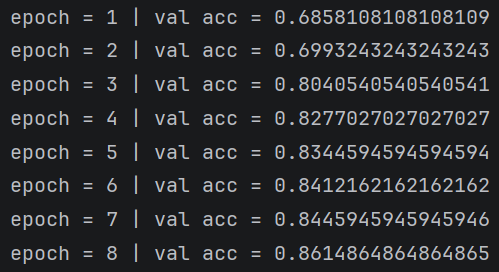
# Layer 4
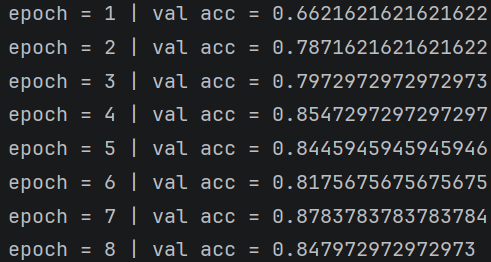
# None
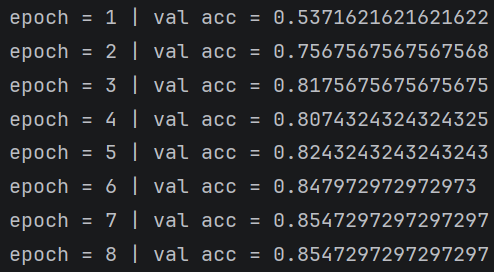
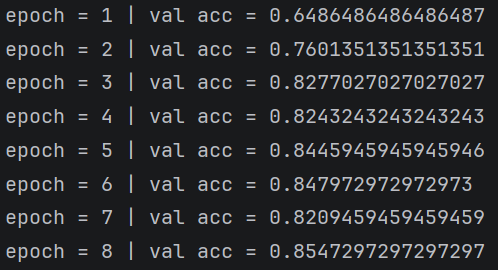
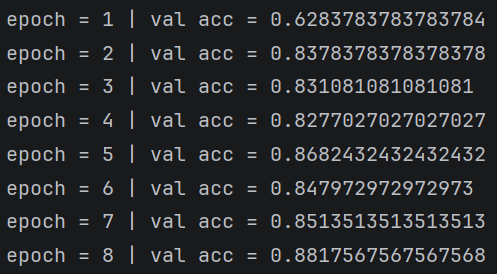
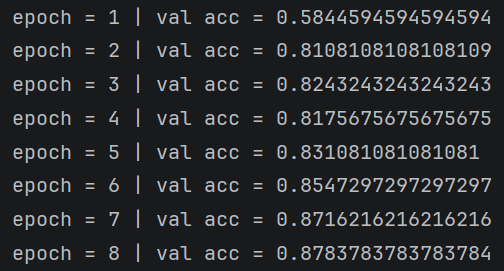
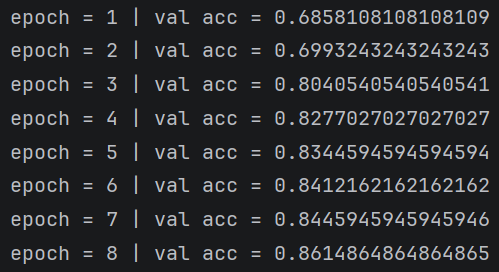

<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q2.7:** سه حالت را بر اساس بهترین validation accuracy رتبه‌بندی کنید. آیا این ترتیب همان چیزی بود که بعد از خواندن Yosinski et al. انتظار داشتید؟ اگر `"all"` با وجود بازکردن بیشترین تعداد پارامترها بهترین نشد، نتیجه را به یک نکته‌ی مشخص از درس «داده‌ی کم» در Session 1 ربط دهید. فقط نگویید «پارامترهای بیشتر overfit می‌کنند»؛ دقیقاً بگویید چه چیزی در این مسئله کوچک است و چه چیزی در مقایسه با آن بزرگ است.

> **پاسخ شما:**
>
layer 4
>
none

all
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۳ — دیدن چیزی که شبکه می‌بیند: Grad-CAM (حدود ۱.۵ ساعت)

تا اینجای ترم تقریباً همه‌چیز را با یک عدد سنجیده‌اید: accuracy. Grad-CAM سؤال کاملاً متفاوتی می‌پرسد: **برای یک پیش‌بینی مشخص، کدام پیکسل‌های تصویر واقعاً تصمیم مدل را هدایت کرده‌اند؟** این ابزار در تمرین کلاسی وجود نداشت و راهی تازه برای نگاه‌کردن *داخل* یک مدل آموزش‌دیده است.

## اول بخوانید: دقیقاً دو معادله

مقاله‌ی Selvaraju et al. با عنوان *"Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"* را باز کنید. دو معادله‌ی اصلی روش را پیدا کنید. این دو اوایل Section 3، درست بعد از معرفی روش، کنار هم آمده‌اند؛ ممکن است شماره‌ی معادله در نسخه‌های مختلف مقاله فرق کند، اما ترتیبشان همیشه یکی است: اول «وزن اهمیت نورون»، بعد heatmap نهایی.

**Q3.1:** معادله‌ی اول برای هر کانال `k` از activation mapهای یک لایه‌ی convolutional انتخاب‌شده، نسبت به کلاس `c` یک وزن $\alpha_k^c$ محاسبه می‌کند. معادله را بنویسید و با بیان خودتان توضیح دهید چه عملی روی $\frac{\partial y^c}{\partial A^k_{ij}}$ انجام می‌شود. راهنما: جمع‌کردن روی موقعیت‌های مکانی $i,j$ و تقسیم بر تعداد آن‌ها یعنی $Z$، عملی آشناست که قبلاً در این ترم استفاده کرده‌اید؛ نامش را بگویید.

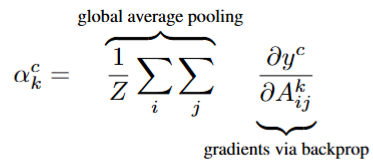
> **پاسخ شما:**
Global average pool
>
ترکیب اطلاعات بصری مهم و موقعیت مکانی به صورت همزمان در لایه آخر نهفته در این فرایند ما به دنبال درک این هستیم که هر فیچر مپ در تشخیص کلاسی خاص مثلا y3 چه میزان فایده داشته است پس برای هر فیچر مپ مشتق لیبل خام اون کلاس رو به هر پیکسل از فیچر مپ مدنظر حساب میکنیم ،
سپس با Global average pool این مشتق را برای تمام آن کانال در  ان لایه محاسبه میکنیم و برای هر کانال یک عدد خواهیم داشت
اگر این عدد مثبت و بزرگ باشد نشان دهنده تاثیر مثبت این فیچر مپ در پیش بینی کلاس هدف است و اگر منفی یا کوچک باشد نشان دهنده بی اثر بودن یا تاثیر منفی در تشخیص است






**Q3.2:** معادله‌ی دوم وزن‌های $\alpha_k^c$ را با activation mapهای $A^k$ ترکیب می‌کند تا heatmap نهایی $L^c_{\text{Grad-CAM}}$ ساخته شود. معادله را بنویسید. چرا مقاله روی مجموع وزن‌دار ReLU اعمال می‌کند و همان مقدار خام را برنمی‌گرداند؟ یک مقدار **منفی** در یک پیکسل چه معنایی دارد و چرا شاید نخواهیم آن را به‌عنوان ناحیه‌ی «مهم» نمایش دهیم؟

> **پاسخ شما:**
> مرحله 2: حالا تمام فیچر مپ ها را در وزن های به دست آمده شان ضرب میکنیم و جمعشان میکنیم و از اکتیویشن فانکشن ReLU عبور میدهیم چون میخواهیم موارد بی ربط یا منفی از بین بروند و فقط تاثیرات مهم باقی بماند
در مرحله بعدی هیتمپ کوچک به دست آمده را با Resize کردن به انداز تصویر خام داده شده به مدل بزرگ میکنیم تا متوجه بشویم مدل به کجای تصویر نگاه کرده تا تشخیص دهد چه اتفاقی افتاده

**Q3.3 (انتخاب محل hook):** Grad-CAM هم به activation mapهای $A^k$ و هم به gradientهایی که به آن‌ها می‌رسند نیاز دارد؛ یعنی باید هنگام forward و backward به خروجی یک لایه‌ی میانی دسترسی داشته باشید، نه فقط به logits نهایی. در ResNet18 خروجی کدام module را هدف می‌گیرید؟ و چرا لازم است این خروجی متعلق به یک لایه‌ی **convolutional** باشد، نه مثلاً خروجی `avgpool` یا `fc`؟ پاسخ را به این نکته وصل کنید که feature map کانولوشنی چه اطلاعاتی را هنوز حفظ می‌کند که یک بردار feature تخت‌شده دیگر ندارد.

> **پاسخ شما:**
در دو سوال بالا هم توضیح داده شد که لایه آخر کانولوشنی هم اطلاعات مفهومی را حفظ میکند ، هم اطلاعات مکانی رو
برای همین باید به دنبال آخرین خروجی لایه کانولوشنی بریم ؛ نه به دنبال اوریجپول یا لایه فولی کانکتد
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

## پیاده‌سازی با hookها

`register_forward_hook` و `register_full_backward_hook` در PyTorch اجازه می‌دهند بدون هیچ تغییری در متد `forward` مدل، خروجی یک لایه و بعداً gradient همان خروجی را بگیرید. این سازوکار فقط برای Grad-CAM نیست و در کاربردهای دیگر هم مفید است.

**TODO:** کلاس `GradCAM` زیر را کامل کنید. لایه‌ی هدف شما `layer4` است؛ آخرین stage کانولوشنی ResNet18.

</div>


In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        # TODO: register a forward hook on `target_layer` that stores its
        #       output into self.activations (detach it, but keep it on DEVICE)
        def forward_hook(module, input, output):
            self.activations = output.detach()
        # TODO: register a full backward hook on `target_layer` that stores
        #       the gradient with respect to its OUTPUT into self.gradients
        #       (grad_output is a tuple; you want grad_output[0], detached)
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, class_index=None):
        '''Run one image (shape [1, 3, 224, 224]) through the model and
        return a single-channel heatmap of shape [H, W] (same H, W as the
        target layer's activation maps).'''
        self.model.eval()
        logits = self.model(input_tensor)

        if class_index is None:
            class_index = logits.argmax(dim=1).item()

        # TODO: zero any existing gradients, then backpropagate from
        #       logits[0, class_index] (a scalar) to populate self.gradients
        #       via the backward hook you registered above.
        self.model.zero_grad()
        target_score = logits[0, class_index]
        target_score.backward()

        # TODO: compute alpha_k = mean of self.gradients over spatial dims (H, W),
        #       for each channel k -- this is Equation "alpha" from Q3.1.
        #       self.gradients has shape [1, C, H, W]; alpha should end up [C].
        alpha = self.gradients.squeeze(0).mean(dim=(1, 2))
        # TODO: compute the weighted sum over channels: sum_k(alpha_k * activations_k),
        #       giving a [H, W] map, then apply ReLU -- this is the second equation.
        activations = self.activations.squeeze(0)

        cam = torch.sum(alpha[:, None, None] * activations, dim=0)
        cam = F.relu(cam)
        # TODO: return the [H, W] heatmap as a numpy array, normalized to [0, 1]
        #       (subtract its min, divide by its max, guarding against divide-by-zero)
        heatmap = cam.cpu().numpy()
        heatmap_min, heatmap_max = heatmap.min(), heatmap.max()

        if heatmap_max - heatmap_min > 1e-8:
            heatmap = (heatmap - heatmap_min) / (heatmap_max - heatmap_min)
        else:
            heatmap = np.zeros_like(heatmap)

        return heatmap

<div class="rtl-fa" dir="rtl" style="text-align: right;">

**TODO:** Grad-CAM را روی ۴ تصویر validation اجرا کنید که `feature_model` شما (baseline فریز‌شده‌ی بخش ۱) آن‌ها را **درست** پیش‌بینی کرده است. Heatmap را روی تصویر اصلی بیندازید. برای این کار heatmap را مثلاً با `cv2.resize` یا `torch.nn.functional.interpolate` به اندازه‌ی `224×224` بزرگ کنید و سپس با یک colormap مثل `"jet"` و `alpha=0.5` روی تصویر اصلی رسم کنید.

</div>


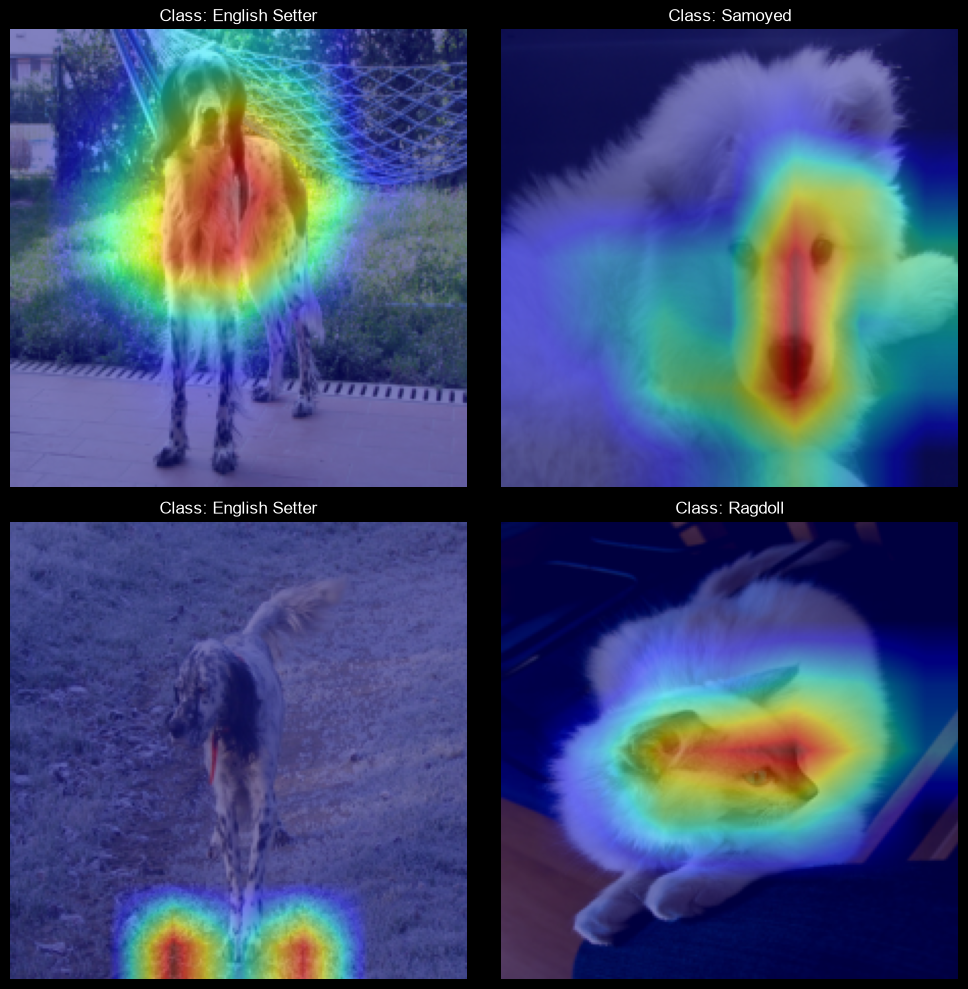

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
set_seed(SEED)
gradcam = GradCAM(feature_model, feature_model.layer4)


def overlay_heatmap(
    image_tensor,
    heatmap,
    ax=None,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
):
    """Denormalizes image_tensor, resizes heatmap to image size, and overlays them."""
    mean_t = torch.tensor(mean, device=image_tensor.device).view(3, 1, 1)
    std_t = torch.tensor(std, device=image_tensor.device).view(3, 1, 1)
    img = image_tensor * std_t + mean_t
    img = img.clamp(0, 1).permute(1, 2, 0).detach().cpu().numpy()

    heatmap_tensor = (
        torch.tensor(heatmap, dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(0)
        .to(image_tensor.device)
    )
    resized_cam = F.interpolate(
        heatmap_tensor,
        size=(img.shape[0], img.shape[1]),
        mode="bilinear",
        align_corners=False,
    )
    resized_cam = resized_cam.squeeze().detach().cpu().numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.imshow(img)
    ax.imshow(resized_cam, cmap="jet", alpha=0.5)
    ax.axis("off")


feature_model.eval()
correct_samples = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = feature_model(images)
        preds = outputs.argmax(dim=1)

        mask = preds == labels
        for img, label, pred in zip(images[mask], labels[mask], preds[mask]):
            correct_samples.append((img, label.item(), pred.item()))
            if len(correct_samples) == 4:
                break
        if len(correct_samples) == 4:
            break


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for idx, (img_tensor, true_label, pred_label) in enumerate(correct_samples):
    ax = axes[idx // 2, idx % 2]


    input_img = img_tensor.unsqueeze(0).clone().detach().requires_grad_(True)

    #  GradCAM
    heatmap = gradcam(input_img, class_index=pred_label)

    breed_name = raw_trainval.classes[pred_label]
    overlay_heatmap(img_tensor, heatmap, ax=ax)
    ax.set_title(f"Class: {breed_name}", fontsize=12)

plt.tight_layout()
plt.show()


# layer 4 -unfreezed Grad-Cam

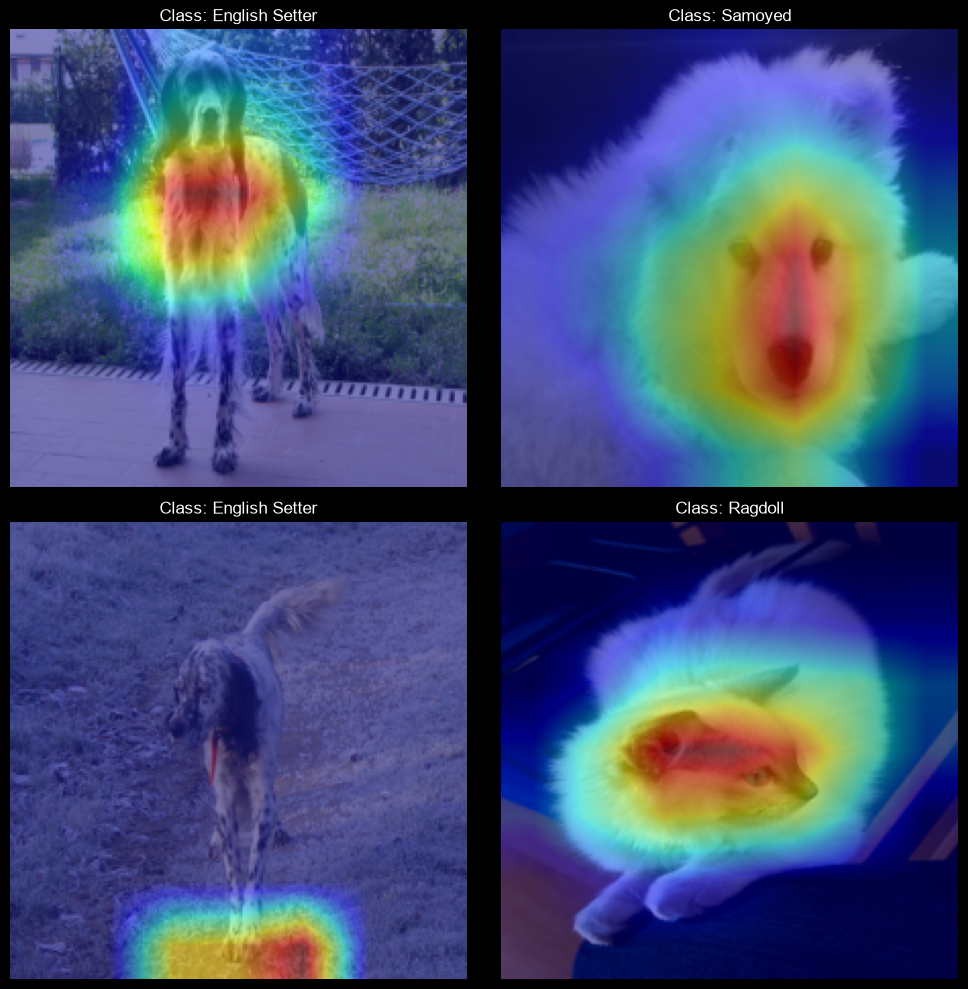

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
set_seed(SEED)
gradcam = GradCAM(model_4, model_4.layer4)


def overlay_heatmap(
    image_tensor,
    heatmap,
    ax=None,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
):
    """Denormalizes image_tensor, resizes heatmap to image size, and overlays them."""
    mean_t = torch.tensor(mean, device=image_tensor.device).view(3, 1, 1)
    std_t = torch.tensor(std, device=image_tensor.device).view(3, 1, 1)
    img = image_tensor * std_t + mean_t
    img = img.clamp(0, 1).permute(1, 2, 0).detach().cpu().numpy()

    heatmap_tensor = (
        torch.tensor(heatmap, dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(0)
        .to(image_tensor.device)
    )
    resized_cam = F.interpolate(
        heatmap_tensor,
        size=(img.shape[0], img.shape[1]),
        mode="bilinear",
        align_corners=False,
    )
    resized_cam = resized_cam.squeeze().detach().cpu().numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.imshow(img)
    ax.imshow(resized_cam, cmap="jet", alpha=0.5)
    ax.axis("off")


model_4.eval()
correct_samples = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model_4(images)
        preds = outputs.argmax(dim=1)

        mask = preds == labels
        for img, label, pred in zip(images[mask], labels[mask], preds[mask]):
            correct_samples.append((img, label.item(), pred.item()))
            if len(correct_samples) == 4:
                break
        if len(correct_samples) == 4:
            break


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for idx, (img_tensor, true_label, pred_label) in enumerate(correct_samples):
    ax = axes[idx // 2, idx % 2]


    input_img = img_tensor.unsqueeze(0).clone().detach().requires_grad_(True)

    #  GradCAM
    heatmap = gradcam(input_img, class_index=pred_label)

    breed_name = raw_trainval.classes[pred_label]
    overlay_heatmap(img_tensor, heatmap, ax=ax)
    ax.set_title(f"Class: {breed_name}", fontsize=12)

plt.tight_layout()
plt.show()


<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q3.4:** به ۴ heatmap نگاه کنید و متقاعدکننده‌ترین مورد را انتخاب کنید؛ یعنی موردی که ناحیه‌ی برجسته‌شده واقعاً شبیه بخشی باشد که یک انسان برای تشخیص آن نژاد به آن توجه می‌کند، مثل شکل گوش، الگوی مو یا صورت. در یک یا دو جمله توضیح دهید heatmap بیشتر روی چه ویژگی بصری متمرکز شده است.

> **پاسخ شما:**
در تشخیص این نمونه از کلاس Samoyed مدل به پوزه جانور و شکل پشمی اطراف سر حیوان دقت کرده و در نمونه بالا سمت راست
> در تفکیک جانور از کلاسMain coon به گوش ها برای تفکیک نگاه کرده
>

**Q3.5 (بخش اصلی — مقایسه‌ی دو مدل):** حالا Grad-CAM را برای **همان یک تصویر** با دو مدل آموزش‌دیده اجرا کنید: `feature_model` فریز‌شده از بخش ۱ و بهترین مدل fine-tuned از بخش ۲ (`"layer4"` یا `"all"`، هرکدام validation accuracy بیشتری داشته است). تصویری انتخاب کنید که heatmapهای دو مدل در آن **واضحاً متفاوت** باشند. در یک یا دو جمله تفاوت را توضیح دهید: آیا fine-tuning توجه مدل را نسبت به مدل فریز‌شده به سمت یک ویژگی اختصاصی‌ترِ نژاد، مثل شکل گوش یا الگوی پوشش بدن، منتقل کرده است؟

> **پاسخ شما:**
در مقایسه با چندین جانور هر دو مدل ( مدل فریز شده ) و مدل ( fine-tune) شده تفاوتی در Grad-Cam نداشتند و برای مثال هر دو برای نژاد گربه رگدال از نیمرخ چپ استفاده کرده بودند یا یکی از تصاویر سگ English setter با پس زمینه شناسایی کرده بودن
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۴ — mixup: افزایشی که برچسب‌ها را هم ترکیب می‌کند (حدود ۱.۵ ساعت)

همه‌ی augmentationهایی که در تمرین‌های Session 1–2 طراحی کردید، هر بار فقط یک تصویر را تغییر می‌دادند و برچسب آن را دست‌نخورده می‌گذاشتند؛ مثلاً یک گربه‌ی flipشده هنوز ۱۰۰٪ «گربه» بود. **mixup** کار متفاوتی می‌کند: **دو** تصویر آموزشی را با هم ترکیب می‌کند و برچسب‌هایشان را هم متناسب با همان ترکیب مخلوط می‌کند. مثلاً نمونه‌ای می‌سازد که «۷۰٪ گربه‌ی Siamese و ۳۰٪ گربه‌ی Persian» است.

## اول بخوانید: دستور دقیق روش

مقاله‌ی Zhang et al. با عنوان *"mixup: Beyond Empirical Risk Minimization"* را باز کنید. معادله‌های اصلی Section 2 را پیدا کنید. این دو معادله بلافاصله بعد از معرفی mixup آمده‌اند و نشان می‌دهند چگونه از دو نمونه‌ی واقعی $(x_i, y_i)$ و $(x_j, y_j)$ یک نمونه‌ی مجازی $(\tilde{x}, \tilde{y})$ ساخته می‌شود.

**Q4.1:** هر دو معادله را بنویسید. $\lambda$ چه نقشی دارد و چه مقادیری می‌تواند بگیرد؟

> **پاسخ شما:**

x˜ = λxi + (1 − λ)xj , where xi, xj are raw input vectors

˜y = λyi + (1 − λ)yj , where yi, yj are one-hot label encodings

$\lambda$درصدی است که سهم هر تصویر از تصویر نهایی را بیان میکند ، برای مثال 70% از یک کلاس و 30% از کلاس دیگر و در هر بچ درصد های تصادفی دریافت میکند تا شدت ترکیب ها متفاوت باشد

**Q4.2:** مقاله $\lambda$ را از توزیع $\text{Beta}(\alpha, \alpha)$ نمونه‌گیری می‌کند، نه اینکه مثلاً همیشه $\lambda = 0.5$ باشد. برای یک $\alpha$ کوچک مثل ۰.۲، بیشتر جرم احتمال نزدیک ۰ و ۱ قرار می‌گیرد و مقدارهای نزدیک ۰.۵ کمتر رخ می‌دهند. با این حساب، در یک batch معمولی که mixup روی آن اعمال شده، بیشتر نمونه‌های مجازی شبیه یک ترکیب واقعی ۵۰/۵۰ هستند یا بیشتر شبیه یک تصویر اصلی با فقط **ردّ کم‌رنگی** از تصویر دوم؟ چرا ممکن است نویسندگان این رفتار را به ترکیب همیشگی و مساوی ترجیح داده باشند؟

### Beta Distribution
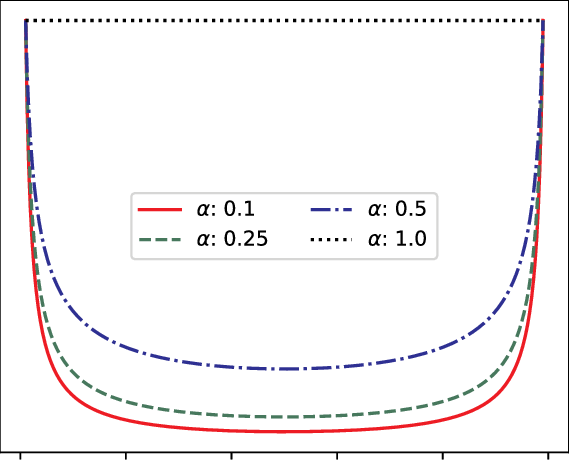>
> **پاسخ شما:**
>
> تصویر بالا که مربوط به توضیح بتا هست نشان میدهد که این توزیع برای a < 1 به سمتی حرکت میکند که بیشتر مقادیر نزدیک 0 و 1 تولید کند
>
> این مفهوم باعث میشود هر تصویر mixup  شده به صورتی باشد که صرفا سایه ای از تصویر دیگر درون خود داشته باشد چون اگر سهم تصویر دیگر خیلی بزرگ باشد مثلا 50 درصد مشکل مفهومی ایجاد میکند و یک تصویر نویزی به وجود می آید که قابل کلاس بندی نیست

**Q4.3 (یک ترفند کارآمد):** مقاله به یک جزئیات پیاده‌سازی اشاره می‌کند: به‌جای دو `DataLoader` جدا برای گرفتن دو تصویر تصادفی مستقل، می‌توانید فقط **یک** batch بگیرید، یک کپی از آن بسازید که نمونه‌هایش **shuffle** شده‌اند، و هر تصویر را با همتای shuffleشده‌ی خودش در همان batch ترکیب کنید. چرا این کار بدون `DataLoader` دوم هم جفت‌های معتبر و ظاهراً مستقل می‌سازد؟ راهنما: فکر کنید permutation تصادفی indexهای یک batch چه تضمینی درباره‌ی جفت‌شدن تصاویر ایجاد می‌کند.

> **پاسخ شما:**
1. با ساختن دوتا Loader مصرف I/O دوبرابر میشه چون دوتا بچ لودر از فضای RAM استفاده میکنن
2. اگر دوتا دیتا لودر داشته باشیم شانس کمی وجود داره که یه نمونه با خودش جفت بشه ولی وقتی یه بچ رو شافل کنیم امکان نداره یه نمونه با خودش میکس بشه
3. وقتی از دو تا دیتا لودر استفاده کنیم ممکنه برخی تصاویر هرگز تصویر مکمل نشن و برخی هرگز تصویر پایه نشن ولی وقتی خود بچ رو شافل کنیم هر تصویر یک مرتبه تصویر مکمل و یک مرتبه تصویر پایه هستش پس از هر تصویر حداکثر استفاده اتفاق میوفته
</div>

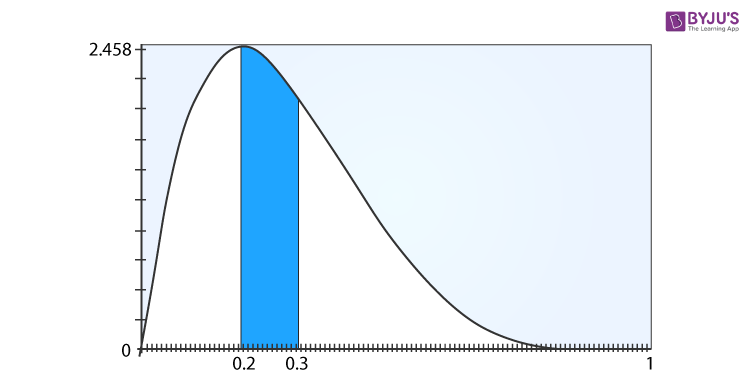
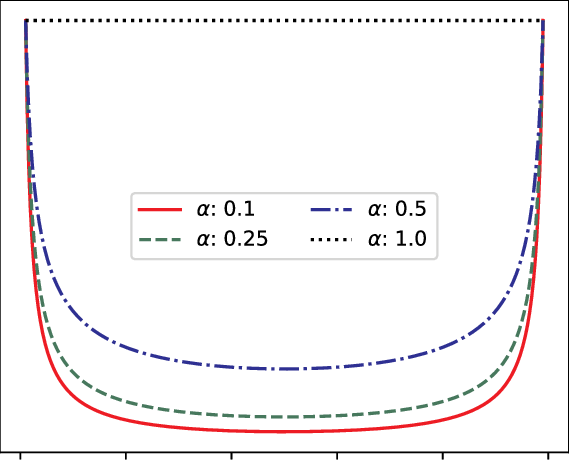

<div class="rtl-fa" dir="rtl" style="text-align: right;">

## پیاده‌سازی

**TODO:** تابع `mixup_batch(images, labels, num_classes, alpha=0.2)` را بنویسید. این تابع باید یک $\lambda$ برای کل batch از `np.random.beta(alpha, alpha)` نمونه بگیرد، یک permutation تصادفی از indexها بسازد، `images` را با نمونه‌های shuffleشده ترکیب کند و برچسب‌های ترکیبی **one-hot** برگرداند. چون برچسب دیگر یک عدد صحیح نیست و به یک توزیع احتمال روی کلاس‌ها تبدیل شده است، `nn.CrossEntropyLoss` می‌تواند soft-label target را مستقیماً بپذیرد، به شرطی که احتمالات کلاس‌ها همان shape مربوط به logits را داشته باشند. گزینه‌ی دیگر این است که loss را دستی به‌صورت `lambda * loss_fn(logits, labels_a) + (1 - lambda) * loss_fn(logits, labels_b)` محاسبه کنید؛ این روش از نظر ریاضی معادل است و نیازی به ساخت one-hot ندارد. هرکدام را انتخاب کردید، واضح بنویسید کدام روش را پیاده‌سازی کرده‌اید.

</div>


In [21]:
def mixup_batch(images, labels, alpha=0.2, seed=None):
    '''Return (mixed_images, labels_a, labels_b, lam) using the
    same-batch-shuffle trick from Q4.3.'''
    if seed is not None:
        np.random.seed(seed)
        set_seed(seed)

    # TODO: sample a single lambda from np.random.beta(alpha, alpha)
    if alpha > 0 :
        lam = np.random.beta(alpha , alpha)
    else:
        lam = 1
    # TODO: build a random permutation of the batch indices (torch.randperm)
    batch_size = images.shape[0]
    permutation = torch.randperm(batch_size,device=images.device)
    # TODO: mixed_images = lam * images + (1 - lam) * images[permutation]
    mixed_images = lam * images + (1- lam) * images[permutation]
    # TODO: labels_a = labels (original order), labels_b = labels[permutation]
    labels_a = labels
    labels_b = labels[permutation]
    # TODO: return mixed_images, labels_a, labels_b, lam
    return mixed_images, labels_a, labels_b, lam


def mixup_loss(loss_fn, logits, labels_a, labels_b, lam):
    # TODO: return lam * loss_fn(logits, labels_a) + (1 - lam) * loss_fn(logits, labels_b)
    return lam * loss_fn(logits, labels_a) + (1.0 - lam) * loss_fn(
        logits, labels_b
    )

<div class="rtl-fa" dir="rtl" style="text-align: right;">

**TODO:** قبل از اینکه به `mixup_batch` در حلقه‌ی training اعتماد کنید، یک sanity-check تصویری انجام دهید: یک تصویر mixed را کنار دو تصویر منبعش رسم کنید و مقدار $\lambda$ نمونه‌گیری‌شده را در عنوان نمایش دهید.

</div>


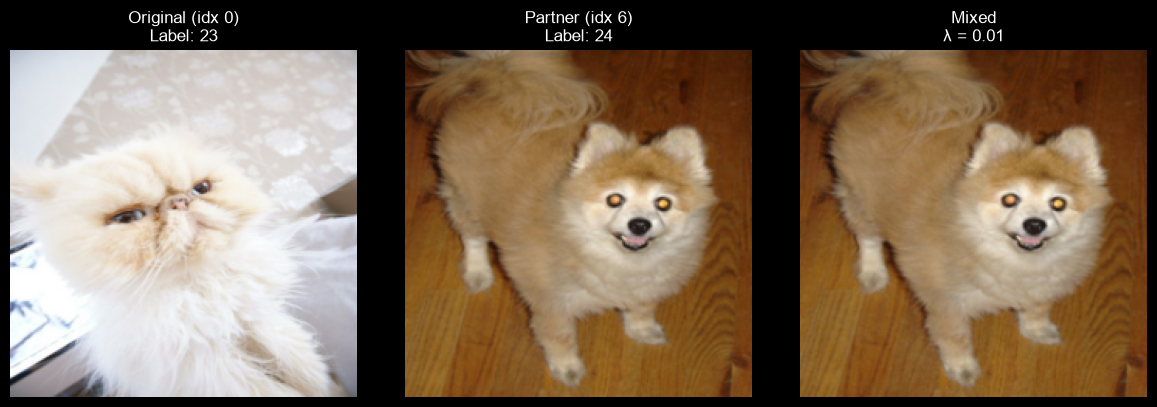

In [22]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN, device=tensor.device).view(
        3, 1, 1
    )
    std = torch.tensor(IMAGENET_STD, device=tensor.device).view(
        3, 1, 1
    )
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)
# TODO: grab one batch from train_loader
set_seed(SEED)
images,labels = next(iter(train_loader))
# TODO: call mixup_batch on it
mixed_images, labels_a, labels_b, lam = mixup_batch(images, labels,seed=42)
# TODO: pick index 0, find its permutation partner, and plot all three images
#       (original, partner, and mixed) side by side with lambda in the title
orig_img = denormalize(images[0].clone()).cpu().permute(1, 2, 0).numpy()
mixed_img = (
    denormalize(mixed_images[0].clone()).cpu().permute(1, 2, 0).numpy()
)


diffs = [
    torch.norm(
        mixed_images[0] - (lam * images[0] + (1 - lam) * images[i])
    ).item()
    for i in range(images.size(0))
]
partner_idx = int(np.argmin(diffs))

partner_img = (
    denormalize(images[partner_idx].clone()).cpu().permute(1, 2, 0).numpy()
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(orig_img)
axes[0].set_title(f"Original (idx 0)\nLabel: {labels_a[0].item()}")
axes[0].axis("off")

axes[1].imshow(partner_img)
axes[1].set_title(
    f"Partner (idx {partner_idx})\nLabel: {labels_b[0].item()}"
)
axes[1].axis("off")

axes[2].imshow(mixed_img)
axes[2].set_title(f"Mixed\nλ = {lam:.2f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q4.4 (قبل از اجرا پیش‌بینی کنید):** mixup در ابتدا روی دیتاست‌هایی ارزیابی شد که برای هر کلاس ده‌ها هزار تصویر داشتند. دیتاست حیوانات ما فقط ۲۰ تصویر از هر نژاد دارد. قبل از اجرای آزمایش زیر پیش‌بینی کنید: روی دیتاست به این کوچکی انتظار دارید mixup کمک کند، عملکرد را بدتر کند یا تفاوت زیادی ایجاد نکند؟ دلیل شما باید به چیزی وصل باشد که mixup اصولاً قرار است اصلاح کند. دوباره انگیزه‌ی بیان‌شده در Abstract مقاله را ببینید: کاهش حفظ‌کردن داده‌ها و حساسیت به ورودی‌های adversarial/غیرعادی. سپس آن را با چیزی مقایسه کنید که واقعاً عملکرد را در یک دیتاست کوچک و ریزدانه مثل این محدود می‌کند.

> **پاسخ شما (پیش‌بینی؛ قبل از اجرای بخش بعدی):**

``` REPORT
Epoch 01/8 | train acc: 26.4% | val acc: 59.1%
Epoch 02/8 | train acc: 75.1% | val acc: 75.3%
Epoch 03/8 | train acc: 87.0% | val acc: 78.7%
Epoch 04/8 | train acc: 92.0% | val acc: 80.4%
Epoch 05/8 | train acc: 92.4% | val acc: 84.1%
Epoch 06/8 | train acc: 96.5% | val acc: 83.1%
Epoch 07/8 | train acc: 97.3% | val acc: 85.5%
Epoch 08/8 | train acc: 97.3% | val acc: 85.5%
```

>
> این گزارش مدل قبل از فریز کردن backbone است در این بخش مدل به وضوح داده های ترین را حفظ کرده بود
>
> از این گزارش نتیجه میگیرم که اگر میکس آپ انجام شود باعث میشود که در اثر رگولاریزیشن و ترکیب عکس ها جلویی مدل برای حفظ تصاویر گرفته شود

**TODO:** دو نسخه از مدل **frozen-feature** خود را آموزش دهید؛ همان روش بخش ۱ را دوباره استفاده کنید و اینجا fine-tuning نکنید تا اثر mixup را جدا از تغییرات بخش ۲ بسنجیم. هر دو مدل را برای تعداد epoch یکسان آموزش دهید: یکی با training معمولی و دیگری با اعمال `mixup_batch`/`mixup_loss` روی هر batch آموزشی. validation باید کاملاً بدون تغییر بماند؛ هنگام ارزیابی mixup اعمال نکنید. دلیل این موضوع را باید از درس «Flickering Metric» در تمرین کلاسی بتوانید توضیح دهید.

</div>


=== Training Plain Model ===
Epoch 01/15 | Train Loss: 0.5387 - Acc: 90.0% | Val Loss: 0.6750 - Acc: 82.8%
Epoch 02/15 | Train Loss: 0.3794 - Acc: 93.8% | Val Loss: 0.6225 - Acc: 83.1%
Epoch 03/15 | Train Loss: 0.3139 - Acc: 95.4% | Val Loss: 0.6408 - Acc: 84.8%
Epoch 04/15 | Train Loss: 0.2646 - Acc: 96.4% | Val Loss: 0.6344 - Acc: 82.1%
Epoch 05/15 | Train Loss: 0.2545 - Acc: 96.2% | Val Loss: 0.6304 - Acc: 83.1%
Epoch 06/15 | Train Loss: 0.2157 - Acc: 97.0% | Val Loss: 0.6244 - Acc: 82.1%
Epoch 07/15 | Train Loss: 0.1969 - Acc: 97.2% | Val Loss: 0.5785 - Acc: 82.8%
Epoch 08/15 | Train Loss: 0.1968 - Acc: 97.2% | Val Loss: 0.5691 - Acc: 85.1%
Epoch 09/15 | Train Loss: 0.1734 - Acc: 98.5% | Val Loss: 0.5674 - Acc: 83.8%
Epoch 10/15 | Train Loss: 0.1553 - Acc: 98.2% | Val Loss: 0.5780 - Acc: 82.8%
Epoch 11/15 | Train Loss: 0.1433 - Acc: 98.2% | Val Loss: 0.5478 - Acc: 84.1%
Epoch 12/15 | Train Loss: 0.1286 - Acc: 98.6% | Val Loss: 0.5615 - Acc: 84.8%
Epoch 13/15 | Train Loss: 0.1339 - 

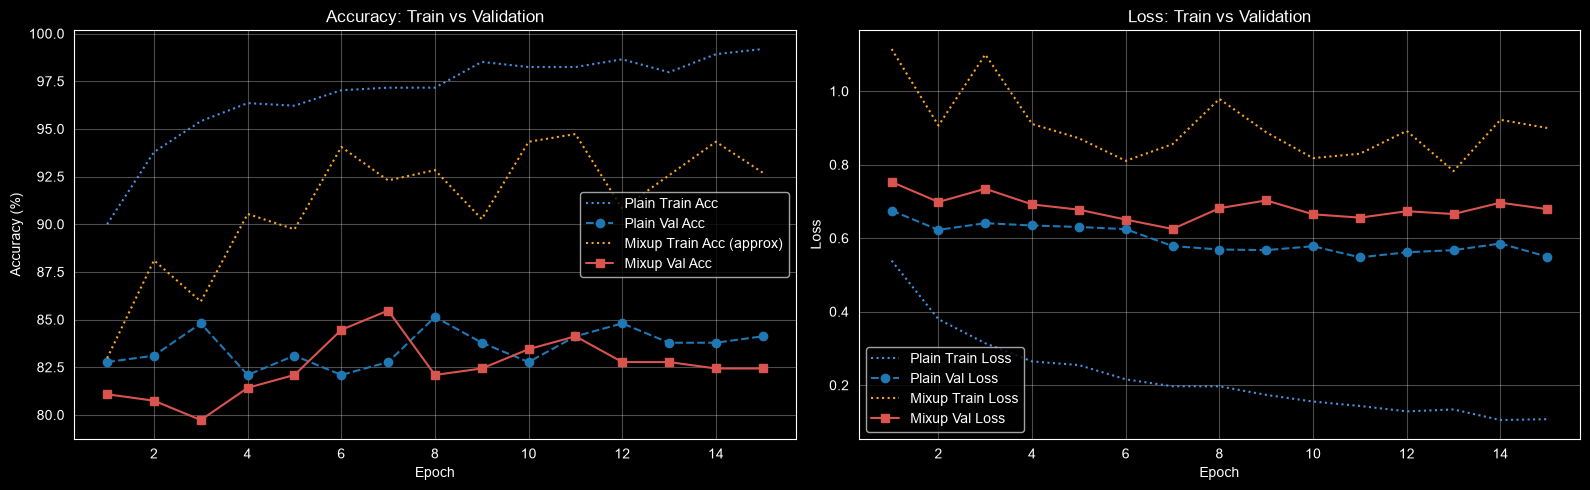

In [23]:
import copy

set_seed(SEED)
NUM_EPOCHS = 15

initial_weights = copy.deepcopy(model.state_dict())

# -------------------------------------------------------------
# ۱. آموزش مدل عادی (Plain Model)
# -------------------------------------------------------------
print("=== Training Plain Model ===")
plain_model = copy.deepcopy(model)
plain_model.load_state_dict(initial_weights)

plain_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, plain_model.parameters()), lr=1e-3
)
criterion = nn.CrossEntropyLoss()

plain_train_losses, plain_train_accs = [], []
plain_val_losses, plain_val_accs = [], []

for epoch in range(NUM_EPOCHS):
    # Training phase
    plain_model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        plain_optimizer.zero_grad()
        logits = plain_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        plain_optimizer.step()

        running_train_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_train_loss / total_train
    train_acc = correct_train / total_train
    plain_train_losses.append(train_loss)
    plain_train_accs.append(train_acc)

    # Validation phase
    plain_model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = plain_model(images)
            loss = criterion(logits, labels)

            running_val_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val
    plain_val_losses.append(val_loss)
    plain_val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.1f}% | "
        f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.1f}%"
    )

# -------------------------------------------------------------
# ۲. آموزش مدل با Mixup (Mixup Model)
# -------------------------------------------------------------
print("\n=== Training Mixup Model ===")
mixup_model = copy.deepcopy(model)
mixup_model.load_state_dict(initial_weights)

mixup_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, mixup_model.parameters()), lr=1e-3
)

mixup_train_losses, mixup_train_accs = [], []
mixup_val_losses, mixup_val_accs = [], []

for epoch in range(NUM_EPOCHS):
    # Training phase with Mixup
    mixup_model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        mixed_images, labels_a, labels_b, lam = mixup_batch(
            images, labels, alpha=0.2
        )

        mixup_optimizer.zero_grad()
        logits = mixup_model(mixed_images)
        loss = mixup_loss(criterion, logits, labels_a, labels_b, lam)
        loss.backward()
        mixup_optimizer.step()

        running_train_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        target_labels = labels_a if lam >= 0.5 else labels_b
        correct_train += (preds == target_labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_train_loss / total_train
    train_acc = correct_train / total_train
    mixup_train_losses.append(train_loss)
    mixup_train_accs.append(train_acc)

    # Validation phase (Clean, No Mixup)
    mixup_model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = mixup_model(images)
            loss = criterion(logits, labels)

            running_val_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val
    mixup_val_losses.append(val_loss)
    mixup_val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} - Acc: {train_acc*100:.1f}% | "
        f"Val Loss: {val_loss:.4f} - Acc: {val_acc*100:.1f}%"
    )

# -------------------------------------------------------------
# ۳. رسم نمودارهای مقایسه‌ای کامل (Train vs Val برای Accuracy و Loss)
# -------------------------------------------------------------
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Accuracies
ax1.plot(
    epochs_range,
    [acc * 100 for acc in plain_train_accs],
    ":",
    color="#4a90e2",
    label="Plain Train Acc",
)
ax1.plot(
    epochs_range,
    [acc * 100 for acc in plain_val_accs],
    "o--",
    color="#1f77b4",
    label="Plain Val Acc",
)
ax1.plot(
    epochs_range,
    [acc * 100 for acc in mixup_train_accs],
    ":",
    color="#f5a623",
    label="Mixup Train Acc (approx)",
)
ax1.plot(
    epochs_range,
    [acc * 100 for acc in mixup_val_accs],
    "s-",
    color="#d9534f",
    label="Mixup Val Acc",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Accuracy: Train vs Validation")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Losses
ax2.plot(
    epochs_range,
    plain_train_losses,
    ":",
    color="#4a90e2",
    label="Plain Train Loss",
)
ax2.plot(
    epochs_range,
    plain_val_losses,
    "o--",
    color="#1f77b4",
    label="Plain Val Loss",
)
ax2.plot(
    epochs_range,
    mixup_train_losses,
    ":",
    color="#f5a623",
    label="Mixup Train Loss",
)
ax2.plot(
    epochs_range,
    mixup_val_losses,
    "s-",
    color="#d9534f",
    label="Mixup Val Loss",
)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Loss: Train vs Validation")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


### Plain model - with out mix-up
``` report
Epoch 01/15 | Train Loss: 0.5387 - Acc: 90.0% | Val Loss: 0.6750 - Acc: 82.8%
Epoch 02/15 | Train Loss: 0.3794 - Acc: 93.8% | Val Loss: 0.6225 - Acc: 83.1%
Epoch 03/15 | Train Loss: 0.3139 - Acc: 95.4% | Val Loss: 0.6408 - Acc: 84.8%
Epoch 04/15 | Train Loss: 0.2646 - Acc: 96.4% | Val Loss: 0.6344 - Acc: 82.1%
Epoch 05/15 | Train Loss: 0.2545 - Acc: 96.2% | Val Loss: 0.6304 - Acc: 83.1%
Epoch 06/15 | Train Loss: 0.2157 - Acc: 97.0% | Val Loss: 0.6244 - Acc: 82.1%
Epoch 07/15 | Train Loss: 0.1969 - Acc: 97.2% | Val Loss: 0.5785 - Acc: 82.8%
Epoch 08/15 | Train Loss: 0.1968 - Acc: 97.2% | Val Loss: 0.5691 - Acc: 85.1%
Epoch 09/15 | Train Loss: 0.1734 - Acc: 98.5% | Val Loss: 0.5674 - Acc: 83.8%
Epoch 10/15 | Train Loss: 0.1553 - Acc: 98.2% | Val Loss: 0.5780 - Acc: 82.8%
Epoch 11/15 | Train Loss: 0.1433 - Acc: 98.2% | Val Loss: 0.5478 - Acc: 84.1%
Epoch 12/15 | Train Loss: 0.1286 - Acc: 98.6% | Val Loss: 0.5615 - Acc: 84.8%
Epoch 13/15 | Train Loss: 0.1339 - Acc: 98.0% | Val Loss: 0.5674 - Acc: 83.8%
Epoch 14/15 | Train Loss: 0.1050 - Acc: 98.9% | Val Loss: 0.5853 - Acc: 83.8%
Epoch 15/15 | Train Loss: 0.1074 - Acc: 99.2% | Val Loss: 0.5495 - Acc: 84.1%
```

``` report
=== Training Mixup Model ===
Epoch 01/15 | Train Loss: 1.1147 - Acc: 83.0% | Val Loss: 0.7529 - Acc: 81.1%
Epoch 02/15 | Train Loss: 0.9063 - Acc: 88.1% | Val Loss: 0.6984 - Acc: 80.7%
Epoch 03/15 | Train Loss: 1.0998 - Acc: 85.9% | Val Loss: 0.7343 - Acc: 79.7%
Epoch 04/15 | Train Loss: 0.9107 - Acc: 90.5% | Val Loss: 0.6918 - Acc: 81.4%
Epoch 05/15 | Train Loss: 0.8718 - Acc: 89.7% | Val Loss: 0.6774 - Acc: 82.1%
Epoch 06/15 | Train Loss: 0.8104 - Acc: 94.1% | Val Loss: 0.6505 - Acc: 84.5%
Epoch 07/15 | Train Loss: 0.8559 - Acc: 92.3% | Val Loss: 0.6250 - Acc: 85.5%
Epoch 08/15 | Train Loss: 0.9789 - Acc: 92.8% | Val Loss: 0.6815 - Acc: 82.1%
Epoch 09/15 | Train Loss: 0.8881 - Acc: 90.3% | Val Loss: 0.7027 - Acc: 82.4%
Epoch 10/15 | Train Loss: 0.8178 - Acc: 94.3% | Val Loss: 0.6649 - Acc: 83.4%
Epoch 11/15 | Train Loss: 0.8298 - Acc: 94.7% | Val Loss: 0.6558 - Acc: 84.1%
Epoch 12/15 | Train Loss: 0.8919 - Acc: 90.8% | Val Loss: 0.6733 - Acc: 82.8%
Epoch 13/15 | Train Loss: 0.7825 - Acc: 92.6% | Val Loss: 0.6656 - Acc: 82.8%
Epoch 14/15 | Train Loss: 0.9220 - Acc: 94.3% | Val Loss: 0.6965 - Acc: 82.4%
Epoch 15/15 | Train Loss: 0.8998 - Acc: 92.7% | Val Loss: 0.6789 - Acc: 82.4%
```

<div class="rtl-fa" dir="rtl" style="text-align: right;">

**Q4.5:** آیا پیش‌بینی Q4.4 شما درست از آب درآمد؟ فارغ از نتیجه، یک تغییر مشخص برای آزمایش پیشنهاد دهید که فکر می‌کنید فرصت منصفانه‌تری به mixup می‌دهد تا روی همین دیتاست مفید بودنش را نشان دهد؛ مثلاً epoch بیشتر، `alpha` متفاوت، تعداد تصویر بیشتر برای هر کلاس، یا استفاده از mixup فقط بعد از بازکردن بخش بیشتری از شبکه. کوتاه توضیح دهید چرا این تغییر می‌تواند کمک کند.

> **پاسخ شما:**
بخشی از پیش بینی من که در رابطه به کاهش گپ بین ترین و ولیدیشن بود درست بود ولی مسئله این هست که دقت نهایی به دست آمده در ولیدیشن کمتر از دقت به دست آمده در مدل خام است پس در کل عملکرد مدل خام حتی بعد از 15 ایپاک هنوز هم بهتر بود  و همگرایی smooth  تری نسبت به همگرایی نوسانی mixed-up داشته
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۵ — تمرین اختیاری: حتی ResNet هم محدودیت دارد (حدود ۳۰ دقیقه)

در بخش ۱ تمرین کلاسی از نتایج **ImageNet** در مقاله‌ی ResNet (Table 2 و Figure 4) استفاده کردید تا مسئله‌ی degradation و نقش residual connectionها در حل آن را بررسی کنید. همان مقاله یک آزمایش دوم روی **CIFAR-10** دارد که خیلی از خوانندگان به آن نمی‌رسند و داستان «residual connection مشکل عمق را حل می‌کند» را کمی پیچیده‌تر می‌کند.

مقاله را باز کنید و **Section 4.2, "CIFAR-10 and Analysis"** را پیدا کنید. نویسندگان شبکه‌های plain و residual با عمق‌های مختلف مثل ۲۰، ۳۲، ۴۴ و ۵۶ لایه را آموزش می‌دهند و بعد، به‌عنوان یک stress test، یک شبکه‌ی residual **بسیار بسیار عمیق** را هم آموزش می‌دهند.

**Q5.1:** عمق عمیق‌ترین شبکه‌ای را که در این بخش آموزش داده شده پیدا کنید؛ دنبال عددی در محدوده‌ی صدها یا بیشتر بگردید. training error آن در مقایسه با یک شبکه‌ی residual خیلی کم‌عمق‌تر، مثلاً مدل ۱۱۰لایه که با همان روش آموزش دیده، چگونه بود؟ شبکه‌ی فوق‌عمیق بهتر بود، بدتر بود یا تقریباً همان عملکرد را داشت؟

> **پاسخ شما:**
>
> 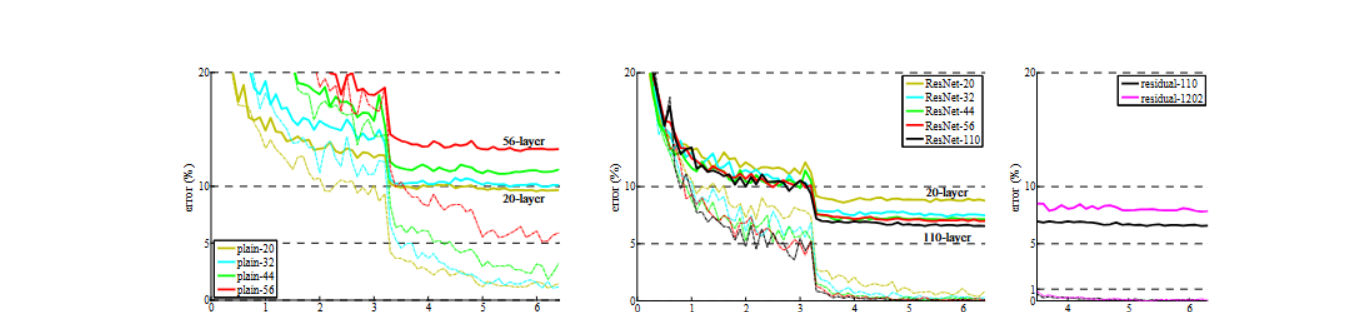
>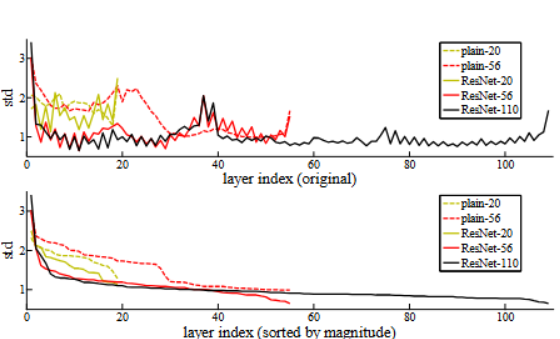
>
با عمیق تر شدن شبکه انحراف معیار لایه ها کمتر و کمتر میشود یعنی لایه ها تغییرات جزئی تری اعمال میکنند که این حالت در 1202 بیشتر از تمام مدل های دیگر است که نشان دهنده رفع مشکل یادنگرفتن مدل در لایه های عمیق است ولی به وضوح مشخص است overfitting رخ داده چون خطای تست با خطای ترین که به صفر بسیار نزدیک است اختلاف زیادی دارد پس چون برای دیتاست ساده و کوچکی مثل CIFAR-10 از رگولاریزیشن استفاده نشده به این وضع دچار شده و مدل حفظ کرده تصاویر ور

**Q5.2 (نکته‌ی ظریف):** در تمرین کلاسی یک بخش کامل صرف تفاوت بین *degradation* — مشکلی در training error که residual connectionها آن را حل می‌کنند — و *overfitting* — مشکلی در generalization — شد. با توجه به چیزی که در Q5.1 پیدا کردید، مشکل شبکه‌ی فوق‌عمیق بیشتر شبیه degradation کلاسیک است، یا مقاله توضیح متفاوتی برای این دارد که چرا حتی با residual connectionها «خیلی عمیق‌تر شدن» دیگر فایده‌ای نداشت؟ توضیح خود مقاله را نقل‌قول کوتاه یا با بیان خودتان بازنویسی کنید.

> **پاسخ شما:**
>
> به بیان خود مقاله overfitting چون خطای ترین بسیار عالی و خطای تست بالا بوده

**Q5.3 (ارتباط با نتایج خودتان):** در بخش ۲ و Q2.7 حالت‌های fine-tuning یعنی `"none"`، `"layer4"` و `"all"` را مقایسه کردید و احتمالاً دیدید که بازکردن *همه‌چیز* روی دیتاست کوچک حیوانات بهترین انتخاب نبود. در **یک جمله** نکته‌ی مشترک بین این نتیجه و چیزی که درباره‌ی ResNet با بیش از ۱۰۰۰ لایه روی CIFAR-10 خواندید را بیان کنید: هر دو مثال‌هایی هستند که در آن «ظرفیت بیشتر برای سازگارشدن» دیگر مجانی نیست. آن منبع محدودی که در هر دو مسئله کم است چیست؟

> **پاسخ شما:**
در مسئله ما هم داده ها محدود بودند و با فعال کردن تمام لایه ها ظرفیت بیش از حدی از یادگیری رو اعمال کردیم که منجر به بیش برازش شد ، در ادامه میکس آپ به ما کمک کرد گپ میان train, test رو کاهش بدیم بنده مایلم در یک مرحله اضافی ترکیبی از mix-up و layer-4 unfreeze داشته باشم
</div>


# تست شخصی ترکیب model-layer4 unfreezed و تکنیک mix-up

=== Starting Layer4 + Mixup Training (BN Frozen) ===
Epoch 01 | Train Loss: 3.1164 - Train Acc: 21.2% | Val Acc: 51.0%
Epoch 02 | Train Loss: 1.4829 - Train Acc: 68.0% | Val Acc: 74.0%
Epoch 03 | Train Loss: 1.0880 - Train Acc: 81.5% | Val Acc: 79.7%
Epoch 04 | Train Loss: 0.9513 - Train Acc: 85.5% | Val Acc: 79.7%
Epoch 05 | Train Loss: 0.8700 - Train Acc: 88.4% | Val Acc: 81.1%
Epoch 06 | Train Loss: 0.8084 - Train Acc: 91.2% | Val Acc: 78.0%
Epoch 07 | Train Loss: 0.8067 - Train Acc: 90.1% | Val Acc: 78.7%
Epoch 08 | Train Loss: 0.7694 - Train Acc: 91.8% | Val Acc: 78.0%
Epoch 09 | Train Loss: 0.7661 - Train Acc: 93.2% | Val Acc: 80.1%
Epoch 10 | Train Loss: 0.7281 - Train Acc: 94.3% | Val Acc: 82.8%
Epoch 11 | Train Loss: 0.7159 - Train Acc: 94.2% | Val Acc: 81.8%
Epoch 12 | Train Loss: 0.7031 - Train Acc: 93.2% | Val Acc: 81.4%
Epoch 13 | Train Loss: 0.6816 - Train Acc: 95.0% | Val Acc: 84.8%
Epoch 14 | Train Loss: 0.6917 - Train Acc: 93.8% | Val Acc: 81.8%
Epoch 15 | Train Loss: 

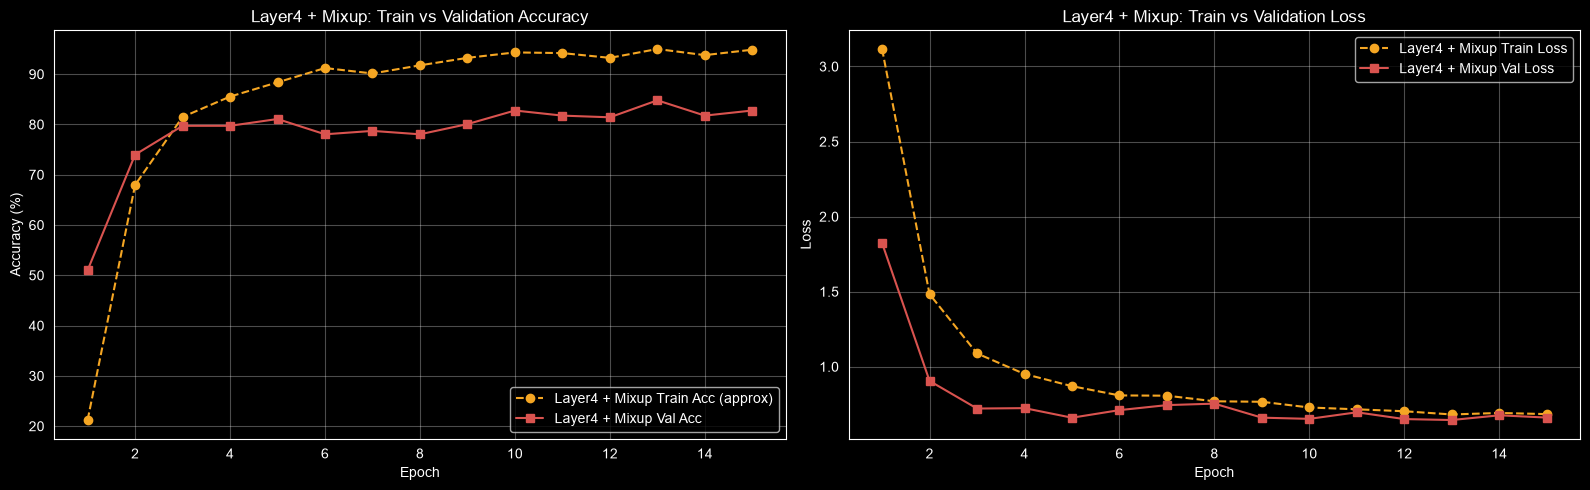

In [24]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
set_seed(SEED)
NUM_EPOCHS = 15
criterion = nn.CrossEntropyLoss()
# ۱. ساخت مدل بهترین وضعیت (Fine-tune لایه ۴)
model_4, optimizer_4 = make_finetune_model("layer4")

mixup_train_losses, mixup_train_accs = [], []
mixup_val_losses, mixup_val_accs = [], []

print("=== Starting Layer4 + Mixup Training (BN Frozen) ===")

for epoch in range(NUM_EPOCHS):
    # Training phase
    model_4.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    # نکته: چون اینجا Mixup داریم، نمی‌توانیم مستقیماً از run_epoch استفاده کنیم
    # پس دقیقا منطقش را با رعایت اصول BatchNorm فریز پیاده می‌کنیم:
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Mixup implementation
        mixed_images, labels_a, labels_b, lam = mixup_batch(images, labels, alpha=0.2)

        # استفاده از مدل در حالت train ولی با BN فریز (باید در هر بچ چک شود)
        # مطابق منطق run_epoch_bn_frozen:
        for module in model_4.trainable_modules:
            module.train()
        for fbn in model_4.layer4.modules(): # فریز کردن BNهای layer4
            if isinstance(fbn, nn.BatchNorm2d):
                fbn.eval()

        optimizer_4.zero_grad()
        logits = model_4(mixed_images)
        loss = mixup_loss(criterion, logits, labels_a, labels_b, lam)
        loss.backward()
        optimizer_4.step()

        running_train_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        target_labels = labels_a if lam >= 0.5 else labels_b
        correct_train += (preds == target_labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_train_loss / total_train
    train_acc = correct_train / total_train
    mixup_train_losses.append(train_loss)
    mixup_train_accs.append(train_acc)

    # Validation phase (استفاده از همان تابع آماده خودت)
    val_metrics = run_epoch_bn_frozen(model_4, val_loader, criterion)
    mixup_val_losses.append(val_metrics["loss"])
    mixup_val_accs.append(val_metrics["accuracy"])

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} - Train Acc: {train_acc*100:.1f}% | Val Acc: {val_metrics['accuracy']*100:.1f}%")

# -------------------------------------------------------------
# رسم Accuracy و Loss
# -------------------------------------------------------------
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

# Accuracy
ax1.plot(
    epochs_range,
    [acc * 100 for acc in mixup_train_accs],
    "o--",
    color="#f5a623",
    label="Layer4 + Mixup Train Acc (approx)"
)

ax1.plot(
    epochs_range,
    [acc * 100 for acc in mixup_val_accs],
    "s-",
    color="#d9534f",
    label="Layer4 + Mixup Val Acc"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Layer4 + Mixup: Train vs Validation Accuracy")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Loss
ax2.plot(
    epochs_range,
    mixup_train_losses,
    "o--",
    color="#f5a623",
    label="Layer4 + Mixup Train Loss"
)

ax2.plot(
    epochs_range,
    mixup_val_losses,
    "s-",
    color="#d9534f",
    label="Layer4 + Mixup Val Loss"
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Layer4 + Mixup: Train vs Validation Loss")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# بخش ۶ — گزارش جمع‌بندی (الزامی، حدود ۳۰ دقیقه)

این همان خروجی اصلی‌ای است که مدیرتان می‌خواند. همه‌ی بخش‌های قبلی مربوط به انجام کار بودند؛ اینجا باید نتیجه را گزارش کنید. یک متن **۲۵۰ تا ۳۵۰ کلمه‌ای** در یک سلول markdown پایین بنویسید، نه در یک فایل جدا. متن باید موارد زیر را پوشش دهد:

1. **گزارش کامل آزمایش‌ها.** جدول زیر را با اعداد واقعی خودتان از همه‌ی آزمایش‌های این هفته کامل کنید: baseline فریز‌شده، fine-tune با `"layer4"`، fine-tune با `"all"` و mixup. برای هر آزمایش یک ردیف بنویسید.

2. **غافلگیرکننده‌ترین نتیجه‌ی این هفته.** لازم نیست بهترین نتیجه باشد؛ نتیجه‌ای را انتخاب کنید که بیشترین تضاد را با انتظار اولیه‌ی شما داشت و توضیح دهید فکر می‌کنید چرا این اتفاق افتاد.

3. **یک پیشنهاد به PetScan.** با توجه به همه‌ی چیزهایی که امتحان کردید، واقعاً کدام مدل/روش را برای استفاده پیشنهاد می‌کنید؟ همراه آن، یک محدودیت یا هشدار مهم هم بنویسید؛ مثلاً کمبود داده، استفاده از فقط یک seed، یا نکته‌ای که Grad-CAM درباره‌ی چیزی که مدل به آن توجه می‌کند یا نمی‌کند نشان داده است.

| آزمایش | Backbone | پارامترهای قابل‌آموزش | بهترین دقت validation | توضیحات                                                                                                                                                                                                                       |
|---|---|-----------------------|-----------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Baseline فریز‌شده (بخش ۱) | فریز | فقط Head              | 85.5                  | در این حالت فقط هد مدل آموزش دیده و تمام لایه های ساخت ویژگی فریز بودند                                                                                                                                                       |
| Fine-tune با `layer4` (بخش ۲) | بخشی باز | لایه 4 و Head         | 87.83                 | به علت اینکه لایه آخر بخش فیچر شبکه های تصویر دارای ویژگی های مفهومی مخصوص هر دیتا هستند لایه آخر که شامل دو بیسیک بلاک بود رو ترین کردیم به علاوه هد مدل                                                                     |
| Fine-tune با `all` (بخش ۲) | کاملاً باز | تمام لایه و پارامتر ها | 86.14                 | در این حالت بسیار آموزش زمان بری داشتیم و لایه های عمومی اولیه که دانش خوبی برای بینایی روی تمام پروژه ها داشتند رو دستخوش تغییر روی یک دیتاست با تعداد نمونه های کم کردیم که این باعث شدن نسبت به روش قبلی دقت کمتری کسب شود |
| Frozen + mixup (بخش ۴) | فریز | فقط Head              | 82.4                  | درست است در این حالت گپ بین ترین و تست کاهش پیدا کرد ولی به علت کم بودن تصاویر و آموزش ندیدن لایه چهارم مدل دقت کلی هم پایین آمد پس مشکل بیش برازش کم شد ولی دقت کلی نسبت به روش های دیگر کمتر شد                             |

> **گزارش جمع‌بندی شما (۲۵۰ تا ۳۵۰ کلمه):**
اتفاق بسیار غافلگیر کننده ای که رخ داد این بود که من تصور میکردم میکس آپ پس از ترکیب شدن با مدل فاین تیون شده ( لایه 4 و هد ، آنفریز) به دقت قابل توجهی دست پیدا کند ! در حالی که  بالاترین دقت ولیدیشن از دقت مدلی که بدون میکس آپ فقط فاین تیون شده بود کمتر بود

علت این اتفاق این بود که داده ها بسیار کم بود و میکس آپ فقط توانسته بود بیش برازش را کاهش دهد و اگر داده کافی میداشتیم فرض من این است که ممکن بود به دقت بالاتری دست پیدا کنیم

به پت اسکن پیشنهاد میکنم با توجه به اینکه حجم داده کمی دارد و تفکیک این تعداد نژاد تنها با این تعداد نمونه 20 تا از هر نمونه ؛ کار سختی است مدل فاین تیون شده ( لایه 4 آنفریز + هد ) را انتخاب کند چرا که بهترین ترکیب در سرعت اجرا و دقت نهایی ولیدیشن بود
گزارشات Grad-Cam  نشان میداد مدل برای پیش بینی برخی نژاد ها به اشتباه به زمینه توجه کرده بود که علت  آن میتواند کم بودن نمونه از آن نژاد ها و همرنگ بودن بدن آن جاندار با اغلیمی که تصویر در آن ثبت شده بود باشد
</div>


<div class="rtl-fa" dir="rtl" style="text-align: right;">

---
# چک‌لیست تحویل

- [ ] بخش ۰: دیتاست به‌درستی بارگذاری و subset ساخته شده و Q0.1 با یک مشاهده‌ی بصری واقعی پاسخ داده شده است
- [ ] بخش ۱: baseline فریز‌شده آموزش داده شده و با Experiment C تمرین کلاسی مقایسه شده است
- [ ] بخش ۲: سؤال‌های مقاله‌ی Yosinski یعنی Q2.1 تا Q2.3 پاسخ داده شده‌اند، `make_finetune_model` پیاده‌سازی و شمارش پارامترهایش بررسی شده، مقایسه‌ی فریز/به‌روزرسانی BatchNorm انجام شده و مقایسه‌ی سه‌حالته‌ی `"none"`/`"layer4"`/`"all"` کامل و رسم شده است
- [ ] بخش ۳: معادله‌های Grad-CAM نوشته شده، کلاس `GradCAM` با hookها پیاده‌سازی شده، heatmap چهار پیش‌بینی درست نمایش داده شده و مقایسه‌ی مدل فریز‌شده با مدل fine-tuned روی یک تصویر انجام شده است
- [ ] بخش ۴: معادله‌های mixup نوشته شده، `mixup_batch`/`mixup_loss` پیاده‌سازی و به‌صورت تصویری sanity-check شده و مقایسه‌ی آموزش معمولی با mixup انجام شده است
- [ ] بخش ۵ (اختیاری): بخش CIFAR-10 مقاله‌ی ResNet خوانده شده و به نتیجه‌ی بخش ۲ خودتان مرتبط شده است
- [ ] بخش ۶: گزارش جمع‌بندی ۲۵۰ تا ۳۵۰ کلمه‌ای همراه با جدول کامل آزمایش‌ها نوشته شده است

## نکته‌ای درباره‌ی نمره‌دهی

 سؤال‌هایی که از شما می‌خواهند چیزی را **بررسی/تأیید** کنید، مثل کنترل تعداد پارامترها در Q2.4 یا پیش‌بینی قبل از اجرا در Q4.4، اهمیت بیشتری دارند. نوشتن صادقانه‌ی «پیش‌بینی من اشتباه بود و دلیلش احتمالاً این است...» ارزش بیشتری از یک روایت غیرواقعی و کاملاً بی‌نقص دارد. در سؤال‌های مقاله، معیار ارزیابی این است که آیا واقعاً با **معادله یا یافته‌ی مشخصی** که به آن ارجاع داده شده درگیر شده‌اید یا نه؛ آشنایی کلی با موضوع کافی نیست. 
</div>
